Name of the Contributors - 
1. Mohammad Walihullah - 20230768
2. Tahiya Jahan Laboni - 20240943
3. Tomas Ribeiro - 20250526
4. Deepak Lakhani - 20231006

In [339]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency


## Import Matplotlib functions to create MiniSOM visualizations

from matplotlib.patches import RegularPolygon, Ellipse
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib import cm, colorbar
from matplotlib import colors as mpl_colors
import matplotlib.pyplot as plt

from matplotlib.colors import LinearSegmentedColormap

from matplotlib.lines import Line2D
import seaborn as sns

from matplotlib import __version__ as mplver
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram
from sklearn.base import clone
import scipy.cluster.hierarchy as sc
from matplotlib.cm import get_cmap

In [342]:
file_path = 'data/DM2425_ABCDEats_DATASET.csv'
df = pd.read_csv(file_path)

In [343]:
df.head()

,customer_id,customer_region,customer_age,vendor_count,product_count,is_chain,first_order,last_order,last_promo,payment_method,...,HR_14,HR_15,HR_16,HR_17,HR_18,HR_19,HR_20,HR_21,HR_22,HR_23
0,1b8f824d5e,2360,18.0,2,5,1,0.0,1,DELIVERY,DIGI,...,0,0,0,0,2,0,0,0,0,0
1,5d272b9dcb,8670,17.0,2,2,2,0.0,1,DISCOUNT,DIGI,...,0,0,0,0,0,0,0,0,0,0
2,f6d1b2ba63,4660,38.0,1,2,2,0.0,1,DISCOUNT,CASH,...,0,0,0,0,0,0,0,0,0,0
3,180c632ed8,4660,NaN,2,3,1,0.0,2,DELIVERY,DIGI,...,1,0,0,0,0,0,0,0,0,0
4,4eb37a6705,4660,20.0,2,5,0,0.0,2,-,DIGI,...,0,0,0,0,0,0,0,0,0,0


## Missing Values

In [345]:
# Assuming 'df' is your DataFrame
rows, columns = df.shape

print(f'Total Rows: {rows}')
print(f'Total Columns: {columns}')


Total Rows: 31888
Total Columns: 56


In [346]:
# Check the dimensions of the dataset
print(f"Dataset shape: {df.shape}")

# Check the data types of each column
print(df.dtypes)

# Basic statistics summary (only for numerical columns)
df.describe()


Dataset shape: (31888, 56)
customer_id                  object
customer_region              object
customer_age                float64
vendor_count                  int64
product_count                 int64
is_chain                      int64
first_order                 float64
last_order                    int64
last_promo                   object
payment_method               object
CUI_American                float64
CUI_Asian                   float64
CUI_Beverages               float64
CUI_Cafe                    float64
CUI_Chicken Dishes          float64
CUI_Chinese                 float64
CUI_Desserts                float64
CUI_Healthy                 float64
CUI_Indian                  float64
CUI_Italian                 float64
CUI_Japanese                float64
CUI_Noodle Dishes           float64
CUI_OTHER                   float64
CUI_Street Food / Snacks    float64
CUI_Thai                    float64
DOW_0                         int64
DOW_1                         int64
D

,customer_age,vendor_count,product_count,is_chain,first_order,last_order,CUI_American,CUI_Asian,CUI_Beverages,CUI_Cafe,...,HR_14,HR_15,HR_16,HR_17,HR_18,HR_19,HR_20,HR_21,HR_22,HR_23
count,31161.000000,31888.000000,31888.000000,31888.000000,31782.000000,31888.000000,31888.000000,31888.000000,31888.000000,31888.000000,...,31888.000000,31888.000000,31888.000000,31888.000000,31888.000000,31888.000000,31888.000000,31888.000000,31888.000000,31888.000000
mean,27.506499,3.102609,5.668245,2.818866,28.478604,63.675521,4.880438,9.960451,2.300633,0.801163,...,0.215630,0.277032,0.356435,0.390962,0.336961,0.245610,0.142812,0.071155,0.048263,0.045189
std,7.160898,2.771587,6.957287,3.977529,24.109086,23.226123,11.654018,23.564351,8.479734,6.427132,...,0.599006,0.738162,0.874449,0.943721,0.893949,0.795296,0.586529,0.348536,0.298265,0.282006
min,15.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,23.000000,1.000000,2.000000,1.000000,7.000000,49.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,26.000000,2.000000,3.000000,2.000000,22.000000,70.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,31.000000,4.000000,7.000000,3.000000,45.000000,83.000000,5.660000,11.830000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,80.000000,41.000000,269.000000,83.000000,90.000000,90.000000,280.210000,896.710000,229.220000,326.100000,...,13.000000,23.000000,22.000000,20.000000,24.000000,35.000000,36.000000,11.000000,15.000000,13.000000


In [347]:
def describe_variables(df, include_non_numeric=False, exclude_zeros=False):
    # Create a DataFrame to store the information
    info_df = pd.DataFrame(columns=['Type', 'First Value', 'Count', 'Mean', 'Std', 'Min',
                                    'Max', 'Quartiles', 'Null Count', 'Zero %', 'Empty %', 'NaN %', '? %'])

    # Iterate over columns
    for col in df.columns:
        data_type = df[col].dtype

        count = mean = std = min_value = max_value = quartiles = first_value = None

        if data_type in ['int64', 'float64']:
            count = df[col].count()
            mean = df[col].mean()
            std = df[col].std()
            min_value = df[col].min()
            max_value = df[col].max()
            quartiles = df[col].quantile([0.25, 0.5, 0.75]).to_dict()
            first_value = df[col].dropna().iloc[0]  # First non-NaN value

        if data_type == 'object':
            first_value = df[col].loc[df[col].ne('').idxmax()]  # First non-empty value

        null_count = df[col].isnull().sum()

        zero_count = df[df[col] == 0].shape[0] if exclude_zeros and data_type in ['int64', 'float64'] else 0
        empty_count = df[df[col] == ''].shape[0] if data_type == 'object' else 0
        nan_count = df[df[col].isna()].shape[0]
        question_count = df[df[col] == '?'].shape[0] if data_type == 'object' else 0

        total_count = len(df)
        zero_percent = (zero_count / total_count) * 100
        empty_percent = (empty_count / total_count) * 100
        nan_percent = (nan_count / total_count) * 100
        question_percent = (question_count / total_count) * 100

        info_df.loc[col] = [data_type, first_value, count, mean, std, min_value,
                            max_value, quartiles, null_count, f'{zero_count} ({zero_percent:.2f}%)',
                            f'{empty_count} ({empty_percent:.2f}%)', f'{nan_count} ({nan_percent:.2f}%)',
                            f'{question_count} ({question_percent:.2f}%)']

    # Set the display width for columns
    pd.set_option('display.max_colwidth', 100)

    return info_df

# Usage:
# Replace 'data' with your actual DataFrame
# Set include_non_numeric=True to include non-numeric variables
# Set exclude_zeros=True to exclude zeros from zero count
result_df = describe_variables(df, include_non_numeric=True, exclude_zeros=True)
result_df

/var/folders/_s/_rkc5yf52mjg60_cwkkrw5yc0000gn/T/ipykernel_1354/2669356588.py:37: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  info_df.loc[col] = [data_type, first_value, count, mean, std, min_value,
/var/folders/_s/_rkc5yf52mjg60_cwkkrw5yc0000gn/T/ipykernel_1354/2669356588.py:37: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  info_df.loc[col] = [data_type, first_value, count, mean, std, min_value,
/var/folders/_s/_rkc5yf52mjg60_cwkkrw5yc0000gn/T/ipykernel_1354/2669356588.py:37: FutureWarning: T

,Type,First Value,Count,Mean,Std,Min,Max,Quartiles,Null Count,Zero %,Empty %,NaN %,? %
customer_id,object,1b8f824d5e,None,NaN,NaN,NaN,NaN,None,0,0 (0.00%),0 (0.00%),0 (0.00%),0 (0.00%)
customer_region,object,2360,None,NaN,NaN,NaN,NaN,None,0,0 (0.00%),0 (0.00%),0 (0.00%),0 (0.00%)
customer_age,float64,18.0,31161,27.506499,7.160898,15.0,80.00,"{0.25: 23.0, 0.5: 26.0, 0.75: 31.0}",727,0 (0.00%),0 (0.00%),727 (2.28%),0 (0.00%)
vendor_count,int64,2,31888,3.102609,2.771587,0.0,41.00,"{0.25: 1.0, 0.5: 2.0, 0.75: 4.0}",0,138 (0.43%),0 (0.00%),0 (0.00%),0 (0.00%)
product_count,int64,5,31888,5.668245,6.957287,0.0,269.00,"{0.25: 2.0, 0.5: 3.0, 0.75: 7.0}",0,156 (0.49%),0 (0.00%),0 (0.00%),0 (0.00%)
is_chain,int64,1,31888,2.818866,3.977529,0.0,83.00,"{0.25: 1.0, 0.5: 2.0, 0.75: 3.0}",0,6104 (19.14%),0 (0.00%),0 (0.00%),0 (0.00%)
first_order,float64,0.0,31782,28.478604,24.109086,0.0,90.00,"{0.25: 7.0, 0.5: 22.0, 0.75: 45.0}",106,1436 (4.50%),0 (0.00%),106 (0.33%),0 (0.00%)
last_order,int64,1,31888,63.675521,23.226123,0.0,90.00,"{0.25: 49.0, 0.5: 70.0, 0.75: 83.0}",0,106 (0.33%),0 (0.00%),0 (0.00%),0 (0.00%)
last_promo,object,DELIVERY,None,NaN,NaN,NaN,NaN,None,0,0 (0.00%),0 (0.00%),0 (0.00%),0 (0.00%)
payment_method,object,DIGI,None,NaN,NaN,NaN,NaN,None,0,0 (0.00%),0 (0.00%),0 (0.00%),0 (0.00%)


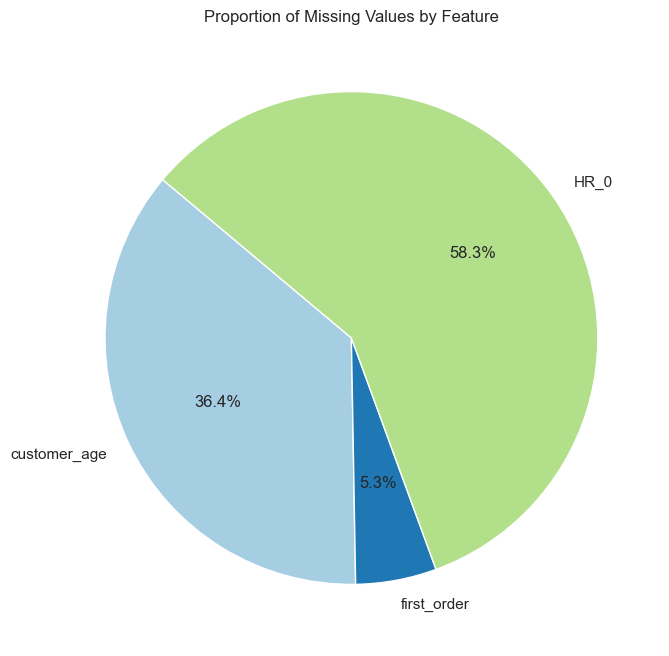

,Missing Values,Percentage
customer_age,727,2.279854
first_order,106,0.332413
HR_0,1165,3.653412


In [348]:
# Checking for missing values in the dataset
missing_values = df.isna().sum()
missing_percentage = (df.isna().sum() / len(df)) * 100

# Combine both count and percentage of missing values for better understanding
missing_summary = pd.DataFrame({'Missing Values': missing_values, 'Percentage': missing_percentage})

# Filter for columns with missing values
missing_summary_filtered = missing_summary[missing_summary['Missing Values'] > 0]

# Checking for missing values in the dataset
missing_values = df.isna().sum()
missing_percentage = (df.isna().sum() / len(df)) * 100

# Combine both count and percentage of missing values for better understanding
missing_summary = pd.DataFrame({'Missing Values': missing_values, 'Percentage': missing_percentage})

# Filter for columns with missing values
missing_summary_filtered = missing_summary[missing_summary['Missing Values'] > 0]

# Plotting a pie chart to display the proportion of missing values
plt.figure(figsize=(8, 8))
plt.pie(missing_summary_filtered['Missing Values'], labels=missing_summary_filtered.index,
        autopct='%1.1f%%', startangle=140, colors=plt.cm.Paired.colors)
plt.title('Proportion of Missing Values by Feature')
plt.show()

# Display the summary of missing values
missing_summary_filtered

plt.show()

# Display the summary of missing values
missing_summary_filtered

## Data Cleaning

## checking the distrubution via visulisation to decide which method can be usefull for handling missing values

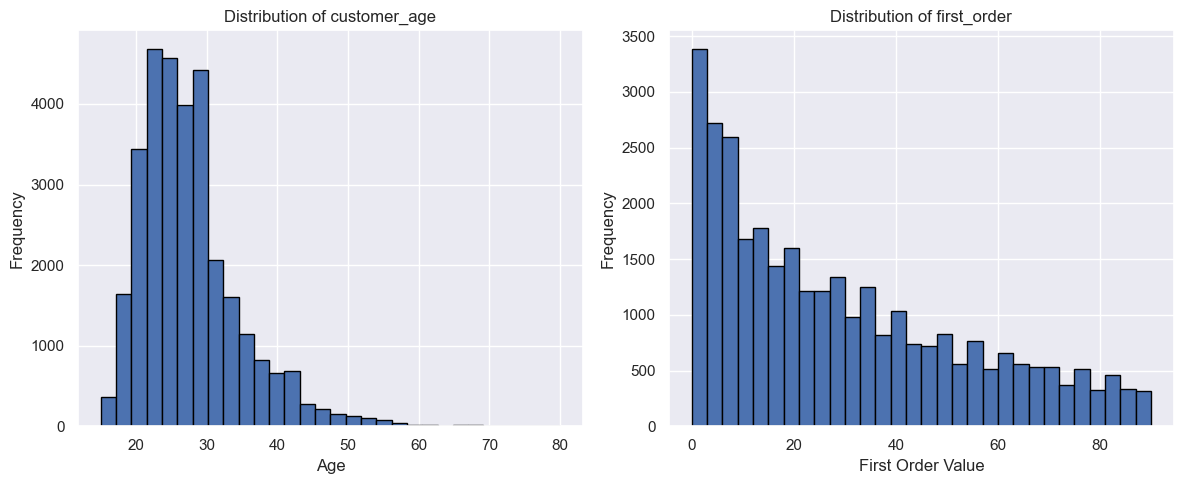

In [351]:
# Plot histograms to visually assess the distribution of 'customer_age' and 'first_order'
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Histogram for customer_age
axes[0].hist(df['customer_age'].dropna(), bins=30, edgecolor='black')
axes[0].set_title('Distribution of customer_age')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Frequency')

# Histogram for first_order
axes[1].hist(df['first_order'].dropna(), bins=30, edgecolor='black')
axes[1].set_title('Distribution of first_order')
axes[1].set_xlabel('First Order Value')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

In [352]:
df["total orders"] = df["DOW_1"]+ df["DOW_2"]+df["DOW_3"]+df["DOW_4"]+df["DOW_5"]+df["DOW_6"]
df["HR_0"].fillna(df["total orders"]-df["HR_23"]-df["HR_22"]-df["HR_21"]-df["HR_20"]-df["HR_19"]-df["HR_18"]-df["HR_17"]-df["HR_16"]-df["HR_15"]-df["HR_14"]-df["HR_13"]-df["HR_12"]-df["HR_11"]-df["HR_10"]-df["HR_9"]-df["HR_8"]-df["HR_7"]-df["HR_6"]-df["HR_5"]-df["HR_4"]-df["HR_3"]-df["HR_2"]-df["HR_1"], inplace=True)

/var/folders/_s/_rkc5yf52mjg60_cwkkrw5yc0000gn/T/ipykernel_1354/4005261258.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["HR_0"].fillna(df["total orders"]-df["HR_23"]-df["HR_22"]-df["HR_21"]-df["HR_20"]-df["HR_19"]-df["HR_18"]-df["HR_17"]-df["HR_16"]-df["HR_15"]-df["HR_14"]-df["HR_13"]-df["HR_12"]-df["HR_11"]-df["HR_10"]-df["HR_9"]-df["HR_8"]-df["HR_7"]-df["HR_6"]-df["HR_5"]-df["HR_4"]-df["HR_3"]-df["HR_2"]-df["HR_1"], inplace=True)


" As It appears both are left skewed and doesnt have outliers so we will be using median for both of these groups and for HR(0), we will try impute zeros for missing values"

In [354]:
# Impute missing values
# Use median for customer_age and first_order, and fill HR_0 with 0
df['customer_age'].fillna(df['customer_age'].median(), inplace=True)
df['first_order'].fillna(df['first_order'].median(), inplace=True)

# Verify that there are no remaining missing values
missing_values_after_imputation = df.isnull().sum()
missing_values_after_imputation

/var/folders/_s/_rkc5yf52mjg60_cwkkrw5yc0000gn/T/ipykernel_1354/1467880573.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['customer_age'].fillna(df['customer_age'].median(), inplace=True)
/var/folders/_s/_rkc5yf52mjg60_cwkkrw5yc0000gn/T/ipykernel_1354/1467880573.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are s

customer_id                 0
customer_region             0
customer_age                0
vendor_count                0
product_count               0
is_chain                    0
first_order                 0
last_order                  0
last_promo                  0
payment_method              0
CUI_American                0
CUI_Asian                   0
CUI_Beverages               0
CUI_Cafe                    0
CUI_Chicken Dishes          0
CUI_Chinese                 0
CUI_Desserts                0
CUI_Healthy                 0
CUI_Indian                  0
CUI_Italian                 0
CUI_Japanese                0
CUI_Noodle Dishes           0
CUI_OTHER                   0
CUI_Street Food / Snacks    0
CUI_Thai                    0
DOW_0                       0
DOW_1                       0
DOW_2                       0
DOW_3                       0
DOW_4                       0
DOW_5                       0
DOW_6                       0
HR_0                        0
HR_1      

## Exploring New Variables

In [356]:
df["Orders on Weekend"] = df["DOW_0"] + df["DOW_6"]
df["Orders on week"] = df["DOW_1"] + df["DOW_2"] + df["DOW_3"] + df["DOW_4"] + df["DOW_5"]
df["Orders in the morning"] = df["HR_7"] + df["HR_8"] + df["HR_9"] + df["HR_10"] + df["HR_11"] + df["HR_12"]
df["Orders in the afternoon"] = df["HR_13"] + df["HR_14"]+df["HR_15"]+df["HR_16"]+df["HR_17"]+df["HR_18"]+ df["HR_19"]
df["Orders in night"] = df["HR_20"]+df["HR_21"]+df["HR_22"]+df["HR_23"]+df["HR_1"]+df["HR_2"]+df["HR_3"]+df["HR_4"]+df["HR_5"]+df["HR_6"]

In [357]:
# List of required DOW and HR columns
dow_columns = {'Orders on Weekend': ['DOW_0', 'DOW_6'],
               'Orders on week': ['DOW_1', 'DOW_2', 'DOW_3', 'DOW_4', 'DOW_5']}
hr_columns = {'Orders in the morning': ['HR_7', 'HR_8', 'HR_9', 'HR_10', 'HR_11', 'HR_12'],
              'Orders in the afternoon': ['HR_13', 'HR_14', 'HR_15', 'HR_16', 'HR_17', 'HR_18', 'HR_19'],
              'Orders in night': ['HR_20', 'HR_21', 'HR_22', 'HR_23', 'HR_1', 'HR_2', 'HR_3', 'HR_4', 'HR_5', 'HR_6']}

# Function to sum columns that exist
def sum_existing_columns(df, column_list):
    existing_columns = [col for col in column_list if col in df.columns]
    if existing_columns:  # Check if there's at least one valid column to sum
        return df[existing_columns].sum(axis=1)
    else:
        return pd.Series([0] * len(df))  # Return 0 if none of the columns exist

# Add new columns by summing existing ones
df["Orders on Weekend"] = sum_existing_columns(df, dow_columns['Orders on Weekend'])
df["Orders on week"] = sum_existing_columns(df, dow_columns['Orders on week'])
df["Orders in the morning"] = sum_existing_columns(df, hr_columns['Orders in the morning'])
df["Orders in the afternoon"] = sum_existing_columns(df, hr_columns['Orders in the afternoon'])
df["Orders in night"] = sum_existing_columns(df, hr_columns['Orders in night'])

# Now the code will work even if some columns are missing


In [358]:
df[["Orders on Weekend", "Orders on week","Orders in the morning", "Orders in the afternoon", "Orders in night"]].describe().T

,count,mean,std,min,25%,50%,75%,max
Orders on Weekend,31888.0,1.260161,1.774096,0.0,0.0,1.0,2.0,35.0
Orders on week,31888.0,3.108662,3.769009,0.0,1.0,2.0,4.0,67.0
Orders in the morning,31888.0,1.464501,2.543379,0.0,0.0,1.0,2.0,71.0
Orders in the afternoon,31888.0,2.059082,3.116409,0.0,0.0,1.0,3.0,62.0
Orders in night,31888.0,0.796538,1.605920,0.0,0.0,0.0,1.0,43.0


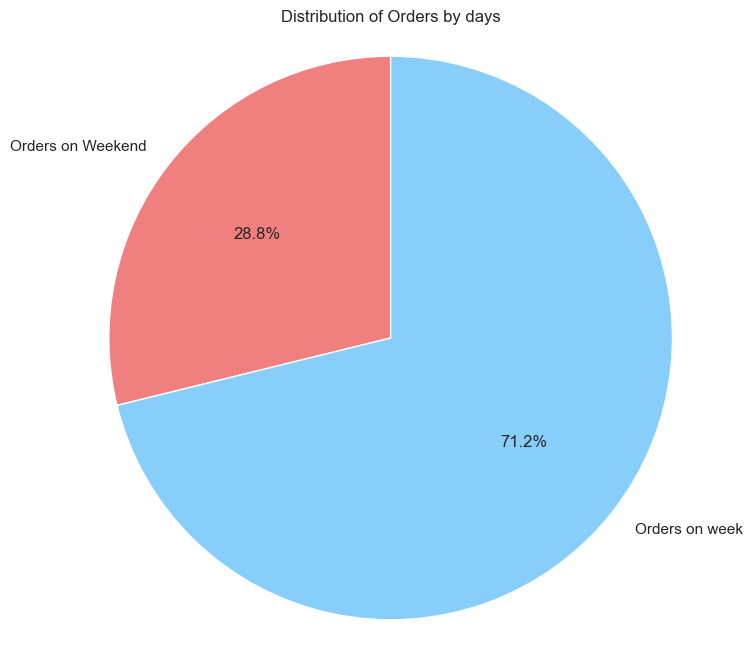

In [359]:
# Data summary for the pie chart
labels = ['Orders on Weekend', 'Orders on week']
sizes = [1.260160561966884, 3.108661565479177]

# Create a pie chart
plt.figure(figsize=(8, 8))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90, colors=['lightcoral', 'lightskyblue', 'lightgreen', 'orange', 'gold'])

# Equal aspect ratio ensures the pie chart is drawn as a circle
plt.axis('equal')
plt.title('Distribution of Orders by days')
plt.show()


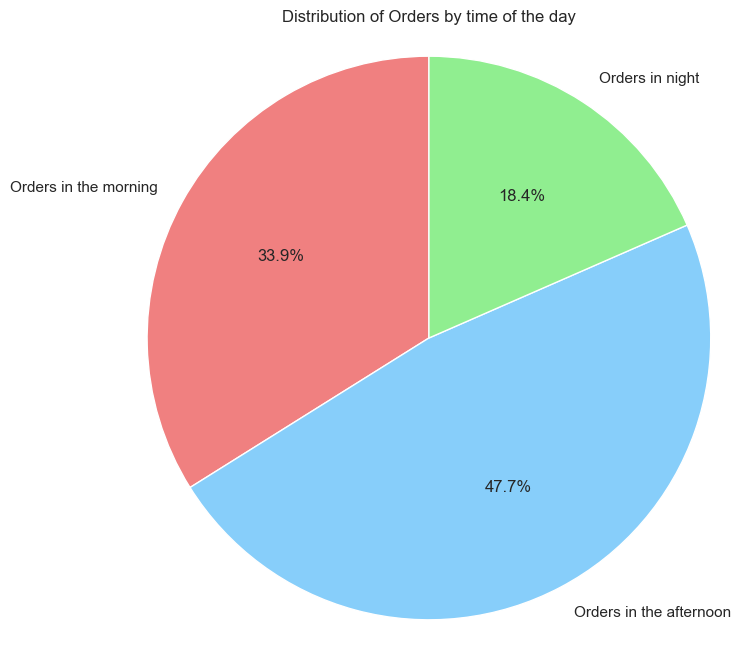

In [360]:
# Data summary for the pie chart
labels = ['Orders in the morning', 'Orders in the afternoon', 'Orders in night']
sizes = [1.4645007526342197, 2.0590817862518818, 0.7965378825890617]

# Create a pie chart
plt.figure(figsize=(8, 8))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90, colors=['lightcoral', 'lightskyblue', 'lightgreen', 'orange', 'gold'])

# Equal aspect ratio ensures the pie chart is drawn as a circle
plt.axis('equal')
plt.title('Distribution of Orders by time of the day')
plt.show()


In [361]:
df["American Cuisine"] = df["CUI_American"]
df["Asian Cuisine"] = df["CUI_Asian"] + df["CUI_Chinese"] + df["CUI_Indian"] + df["CUI_Japanese"] + df["CUI_Thai"]
df["European Cuisine"] = df["CUI_Italian"]
df["Snacks & Beverages"] = df["CUI_Beverages"] + df["CUI_Cafe"] + df["CUI_Desserts"] + df["CUI_Street Food / Snacks"]
df["Other Cuisine"] = df["CUI_Noodle Dishes"] + df["CUI_Chicken Dishes"] + df["CUI_Healthy"] + df["CUI_OTHER"]

   American Cuisine  Asian Cuisine  European Cuisine  Snacks & Beverages  \
0              0.00          28.88               0.0                 0.0   
1             12.82           6.39               0.0                 0.0   
2              9.20           0.00               0.0                 0.0   
3              0.00          31.56               0.0                 0.0   
4             14.57          40.87               0.0                 0.0   

   Other Cuisine  
0            0.0  
1            0.0  
2            0.0  
3            0.0  
4            0.0  


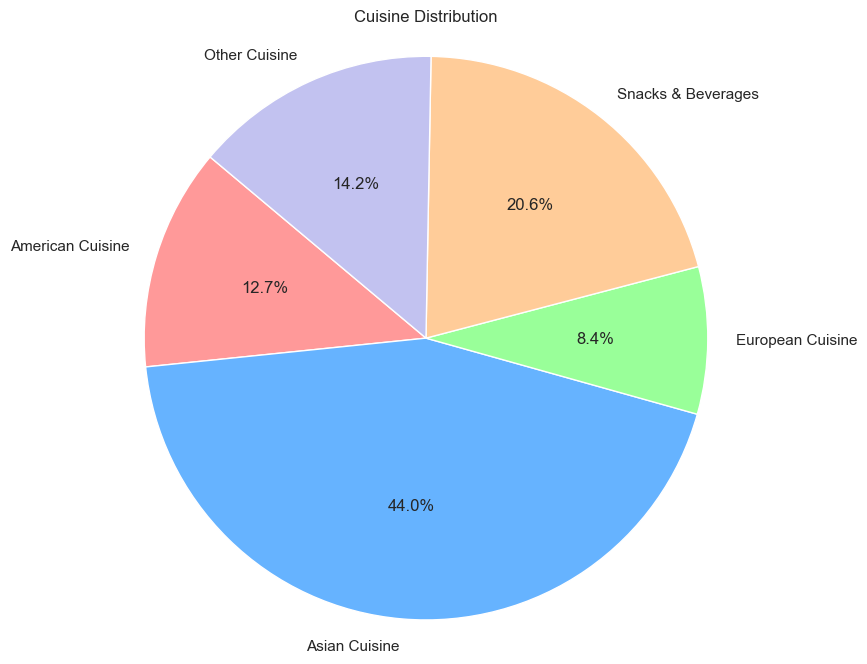

In [362]:
# Create new columns for the aggregated cuisine data
df["American Cuisine"] = df["CUI_American"]
df["Asian Cuisine"] = df["CUI_Asian"] + df["CUI_Chinese"] + df["CUI_Indian"] + df["CUI_Japanese"] + df["CUI_Thai"]
df["European Cuisine"] = df["CUI_Italian"]
df["Snacks & Beverages"] = df["CUI_Beverages"] + df["CUI_Cafe"] + df["CUI_Desserts"] + df["CUI_Street Food / Snacks"]
df["Other Cuisine"] = df["CUI_Noodle Dishes"] + df["CUI_Chicken Dishes"] + df["CUI_Healthy"] + df["CUI_OTHER"]

# Check if the columns were added
print(df[["American Cuisine", "Asian Cuisine", "European Cuisine", "Snacks & Beverages", "Other Cuisine"]].head())

# Calculate the total counts for each cuisine category for the pie chart
cuisine_data = {
    'American Cuisine': df["American Cuisine"].sum(),
    'Asian Cuisine': df["Asian Cuisine"].sum(),
    'European Cuisine': df["European Cuisine"].sum(),
    'Snacks & Beverages': df["Snacks & Beverages"].sum(),
    'Other Cuisine': df["Other Cuisine"].sum()
}

# Labels and sizes for the pie chart
labels = cuisine_data.keys()
sizes = cuisine_data.values()
colors = ['#ff9999','#66b3ff','#99ff99','#ffcc99', '#c2c2f0']

# Plotting the pie chart
plt.figure(figsize=(8, 8))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=140, colors=colors)
plt.title('Cuisine Distribution')
plt.axis('equal')  # Equal aspect ratio ensures the pie chart is circular.

# Show the pie chart
plt.show()


/var/folders/_s/_rkc5yf52mjg60_cwkkrw5yc0000gn/T/ipykernel_1354/2627357195.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Cuisine', y='Number of Customers', data=cuisine_counts_df, palette='coolwarm')


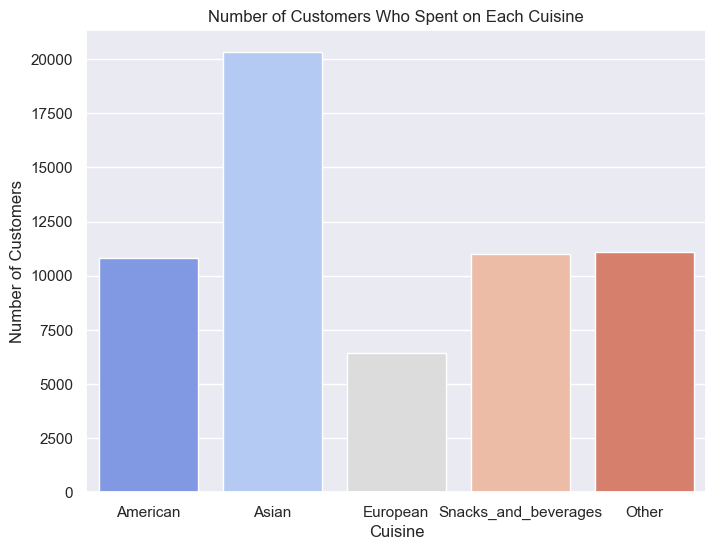

In [363]:
cuisine_counts = {
    'American': (df['American Cuisine'] > 0).sum(),
    'Asian': (df['Asian Cuisine'] > 0).sum(),
    'European': (df['European Cuisine'] > 0).sum(),
    'Snacks_and_beverages': (df['Snacks & Beverages'] > 0).sum(),
    'Other': (df['Other Cuisine'] > 0).sum()
}

cuisine_counts_df = pd.DataFrame(list(cuisine_counts.items()), columns=['Cuisine', 'Number of Customers'])

# Plot
plt.figure(figsize=(8, 6))
sns.barplot(x='Cuisine', y='Number of Customers', data=cuisine_counts_df, palette='coolwarm')

# Adding title and labels
plt.title("Number of Customers Who Spent on Each Cuisine")
plt.xlabel("Cuisine")
plt.ylabel("Number of Customers")
plt.show()


In [364]:
# Assuming each cuisine column represents the amount spent by the customer on that cuisine
df['total_amount_spent'] = (
    df['American Cuisine'] +
    df['Asian Cuisine'] +
    df['European Cuisine'] +
    df['Snacks & Beverages'] +
    df['Other Cuisine']
)


In [365]:
# Group by customer and payment method to get the total spending per customer per payment type
customer_payment_spending = df.groupby(['customer_id', 'payment_method'])['total_amount_spent'].sum().reset_index()

# Display results
print("Total Amount Spent by Customer and Payment Method:")
print(customer_payment_spending.head())


Total Amount Spent by Customer and Payment Method:
  customer_id payment_method  total_amount_spent
0  000063815c           DIGI               42.63
1  0000e01e15           CARD               48.56
2  000113e2b5           DIGI              144.59
3  000206f7fa           CARD               22.50
4  0005917bd7           CASH               39.93


In [366]:
# Group by chain affiliation and calculate the total and average spending
chain_spending = df.groupby('is_chain')['total_amount_spent'].agg(['sum', 'mean']).reset_index()

# Display results
print("Total and Average Spending by Chain Affiliation:")
print(chain_spending)


Total and Average Spending by Chain Affiliation:
    is_chain        sum         mean
0          0  168654.93    27.630231
1          1  204304.29    23.903626
2          2  177400.26    30.103557
3          3  140369.49    37.958218
4          4  100729.37    46.526268
5          5   72649.60    52.644638
6          6   58399.85    61.733457
7          7   46403.48    68.340913
8          8   38215.34    76.430680
9          9   32039.83    85.667995
10        10   24827.62    85.318282
11        11   22122.55    89.203831
12        12   16317.82    96.555148
13        13   14886.81    97.939539
14        14   13215.13    95.761812
15        15    9883.65   111.052247
16        16    9177.06   134.956765
17        17    7394.16   134.439273
18        18    8037.63   123.655846
19        19    4257.25   121.635714
20        20    4766.65   140.195588
21        21    3788.04   130.622069
22        22    3753.76   144.375385
23        23    2657.11   132.855500
24        24    3551.82   

In [367]:
df["is_chain"].unique()

array([ 1,  2,  0,  3,  5,  4,  7, 12,  6, 23,  8, 11, 20, 14,  9, 10, 16,
       15, 13, 25, 17, 27, 30, 32, 24, 18, 26, 28, 22, 40, 31, 39, 21, 37,
       19, 33, 65, 38, 29, 45, 47, 73, 81, 56, 35, 46, 67, 44, 61, 34, 36,
       49, 83, 75, 43, 42, 48, 63, 54, 80])

In [368]:
# Step 2: Group by chain affiliation and calculate total and average spending on cuisines
chain_cuisine_spending = df.groupby('is_chain')['total_amount_spent'].agg(['sum', 'mean']).reset_index()

# Display results
print("Total and Average Cuisine Spending by Chain Affiliation:")
print(chain_cuisine_spending)


Total and Average Cuisine Spending by Chain Affiliation:
    is_chain        sum         mean
0          0  168654.93    27.630231
1          1  204304.29    23.903626
2          2  177400.26    30.103557
3          3  140369.49    37.958218
4          4  100729.37    46.526268
5          5   72649.60    52.644638
6          6   58399.85    61.733457
7          7   46403.48    68.340913
8          8   38215.34    76.430680
9          9   32039.83    85.667995
10        10   24827.62    85.318282
11        11   22122.55    89.203831
12        12   16317.82    96.555148
13        13   14886.81    97.939539
14        14   13215.13    95.761812
15        15    9883.65   111.052247
16        16    9177.06   134.956765
17        17    7394.16   134.439273
18        18    8037.63   123.655846
19        19    4257.25   121.635714
20        20    4766.65   140.195588
21        21    3788.04   130.622069
22        22    3753.76   144.375385
23        23    2657.11   132.855500
24        24    35

/var/folders/_s/_rkc5yf52mjg60_cwkkrw5yc0000gn/T/ipykernel_1354/616220752.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=chain_cuisine_spending, x='is_chain', y='sum', palette="viridis")
/var/folders/_s/_rkc5yf52mjg60_cwkkrw5yc0000gn/T/ipykernel_1354/616220752.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=chain_cuisine_spending, x='is_chain', y='mean', palette="viridis")


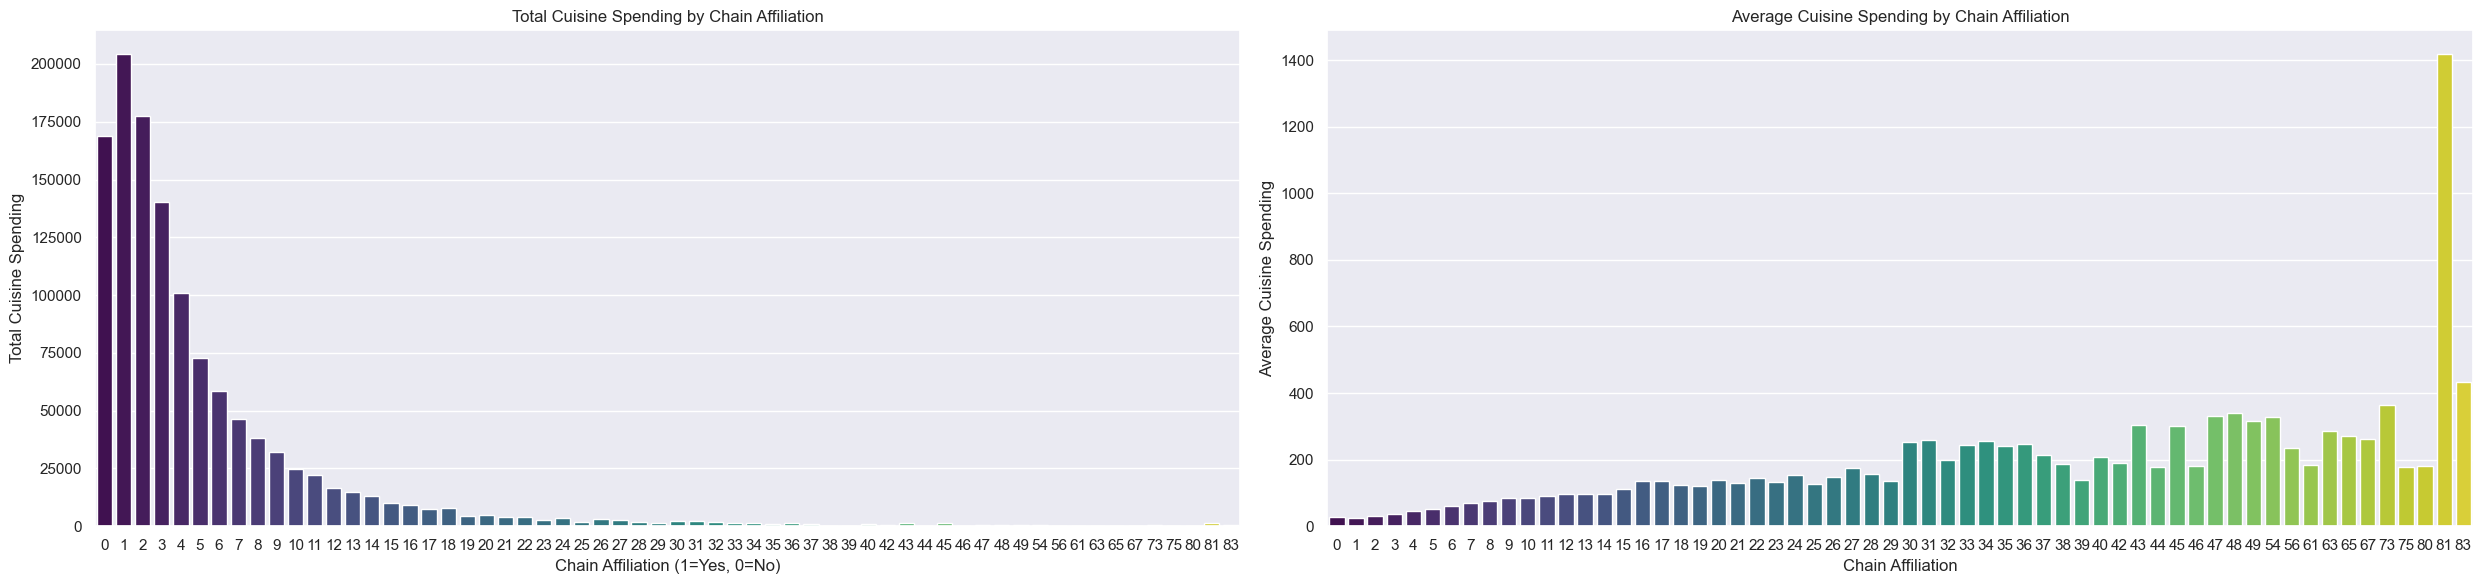

In [369]:
# Plotting the total and average cuisine spending by chain affiliation
plt.figure(figsize=(25, 6))

# Bar plot for total cuisine spending
plt.subplot(1, 2, 1)
sns.barplot(data=chain_cuisine_spending, x='is_chain', y='sum', palette="viridis")
plt.title('Total Cuisine Spending by Chain Affiliation')
plt.xlabel('Chain Affiliation (1=Yes, 0=No)')
plt.ylabel('Total Cuisine Spending')

# Bar plot for average cuisine spending
plt.subplot(1, 2, 2)
sns.barplot(data=chain_cuisine_spending, x='is_chain', y='mean', palette="viridis")
plt.title('Average Cuisine Spending by Chain Affiliation')
plt.xlabel('Chain Affiliation')
plt.ylabel('Average Cuisine Spending')

plt.tight_layout()
plt.show()


/var/folders/_s/_rkc5yf52mjg60_cwkkrw5yc0000gn/T/ipykernel_1354/3795754538.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=payment_spending, x='payment_method', y='sum', palette="Blues", ax=axes[0])
/var/folders/_s/_rkc5yf52mjg60_cwkkrw5yc0000gn/T/ipykernel_1354/3795754538.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=payment_spending, x='payment_method', y='mean', palette="Oranges", ax=axes[1])


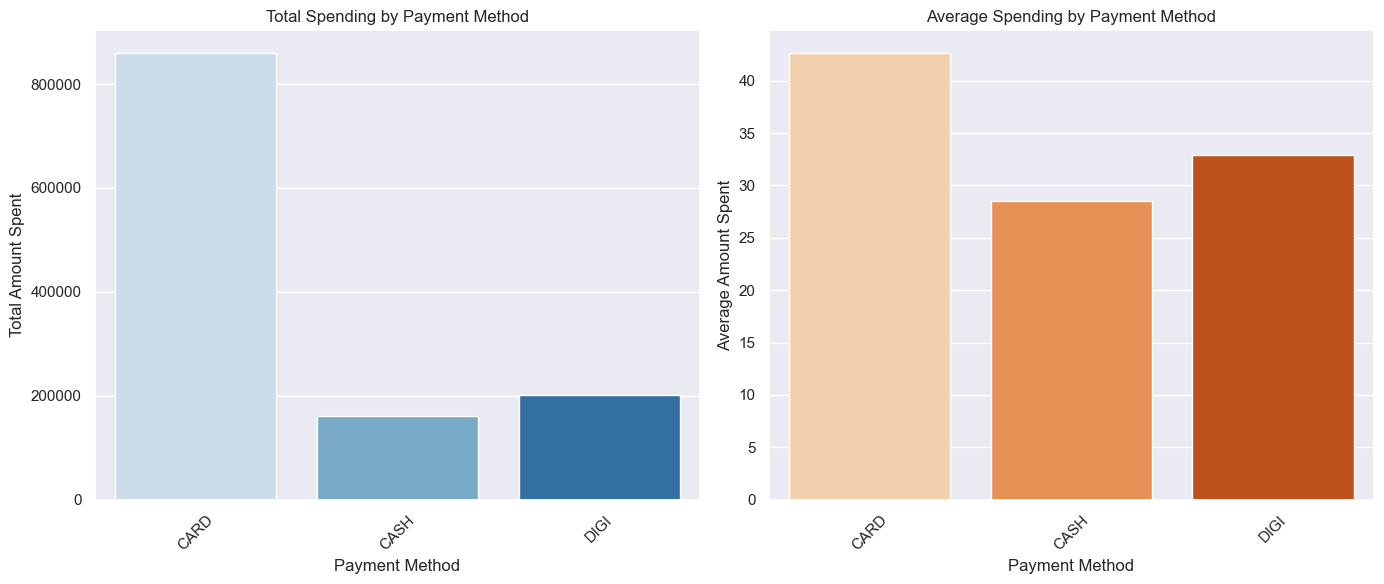

In [370]:
# Group by payment method and calculate total and average spending
payment_spending = df.groupby('payment_method')['total_amount_spent'].agg(['sum', 'mean']).reset_index()

# Set up the figure and axes
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot total spending by payment method
sns.barplot(data=payment_spending, x='payment_method', y='sum', palette="Blues", ax=axes[0])
axes[0].set_title('Total Spending by Payment Method')
axes[0].set_xlabel('Payment Method')
axes[0].set_ylabel('Total Amount Spent')
axes[0].tick_params(axis='x', rotation=45)  # Rotate x-axis labels for readability

# Plot average spending by payment method
sns.barplot(data=payment_spending, x='payment_method', y='mean', palette="Oranges", ax=axes[1])
axes[1].set_title('Average Spending by Payment Method')
axes[1].set_xlabel('Payment Method')
axes[1].set_ylabel('Average Amount Spent')
axes[1].tick_params(axis='x', rotation=45)  # Rotate x-axis labels for readability

# Adjust layout
plt.tight_layout()

# Display the plot
plt.show()


In [371]:
# Calculate order frequency
df['order_frequency'] = df['last_order'] - df['first_order'] / df['product_count']

# Define age groups and categorize customers
age_bins = [0, 24, 50, 100]
age_labels = ['Young', 'Middle-Aged', 'Senior']
df['age_group'] = pd.cut(df['customer_age'], bins=age_bins, labels=age_labels, right=False)

In [372]:
print(df['age_group'].value_counts())


age_group
Middle-Aged    21318
Young          10126
Senior           444
Name: count, dtype: int64


In [373]:
print(df['age_group'].isna().sum())


0


In [374]:
df['customer_region']


0        2360
1        8670
2        4660
3        4660
4        4660
         ... 
31883    8670
31884    8670
31885    8670
31886    8670
31887    4660
Name: customer_region, Length: 31888, dtype: object

In [375]:
print(df['product_count'].value_counts())


product_count
2      6287
3      4971
1      4691
4      3406
5      2382
       ... 
117       1
110       1
83        1
84        1
68        1
Name: count, Length: 93, dtype: int64


In [376]:
print(df['order_frequency'].isna().sum())  # Check for NaNs
print((df['order_frequency'] == float('inf')).sum())  # Check for positive infinity
print((df['order_frequency'] == float('-inf')).sum())  # Check for negative infinity


0
0
156


In [377]:
# Drop rows where 'order_frequency' is NaN or infinite
df = df.replace([float('inf'), float('-inf')], np.nan).dropna(subset=['order_frequency'])


In [378]:
df.columns

Index(['customer_id', 'customer_region', 'customer_age', 'vendor_count',
       'product_count', 'is_chain', 'first_order', 'last_order', 'last_promo',
       'payment_method', 'CUI_American', 'CUI_Asian', 'CUI_Beverages',
       'CUI_Cafe', 'CUI_Chicken Dishes', 'CUI_Chinese', 'CUI_Desserts',
       'CUI_Healthy', 'CUI_Indian', 'CUI_Italian', 'CUI_Japanese',
       'CUI_Noodle Dishes', 'CUI_OTHER', 'CUI_Street Food / Snacks',
       'CUI_Thai', 'DOW_0', 'DOW_1', 'DOW_2', 'DOW_3', 'DOW_4', 'DOW_5',
       'DOW_6', 'HR_0', 'HR_1', 'HR_2', 'HR_3', 'HR_4', 'HR_5', 'HR_6', 'HR_7',
       'HR_8', 'HR_9', 'HR_10', 'HR_11', 'HR_12', 'HR_13', 'HR_14', 'HR_15',
       'HR_16', 'HR_17', 'HR_18', 'HR_19', 'HR_20', 'HR_21', 'HR_22', 'HR_23',
       'total orders', 'Orders on Weekend', 'Orders on week',
       'Orders in the morning', 'Orders in the afternoon', 'Orders in night',
       'American Cuisine', 'Asian Cuisine', 'European Cuisine',
       'Snacks & Beverages', 'Other Cuisine', 'total_amo

/var/folders/_s/_rkc5yf52mjg60_cwkkrw5yc0000gn/T/ipykernel_1354/3416662482.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_group_orders = df.groupby('age_group')['order_frequency'].sum()


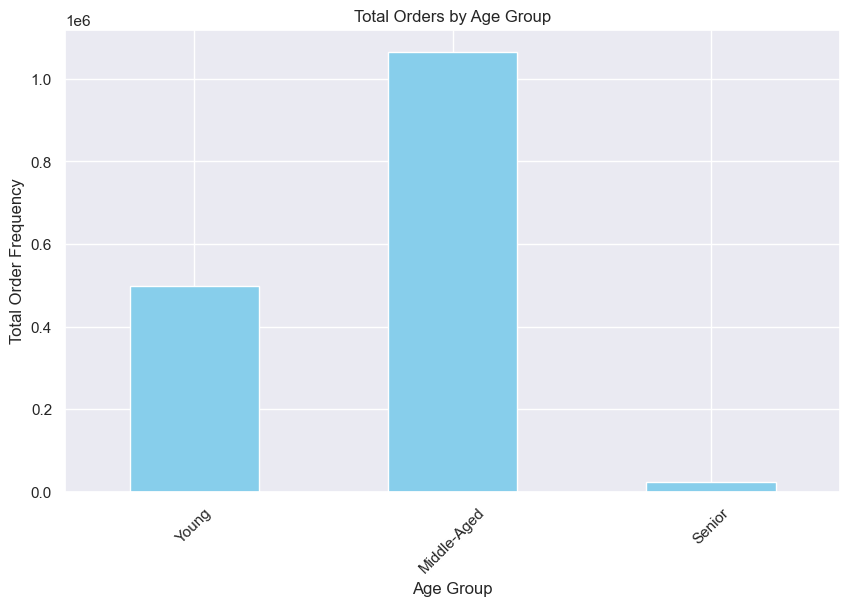

In [379]:
# Recalculate the total order frequency by age group
age_group_orders = df.groupby('age_group')['order_frequency'].sum()

# Plot the results
plt.figure(figsize=(10, 6))
age_group_orders.plot(kind='bar', color='skyblue')
plt.title('Total Orders by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Total Order Frequency')
plt.xticks(rotation=45)
plt.show()


**Pie Chart: Customer Distribution by Age Group**

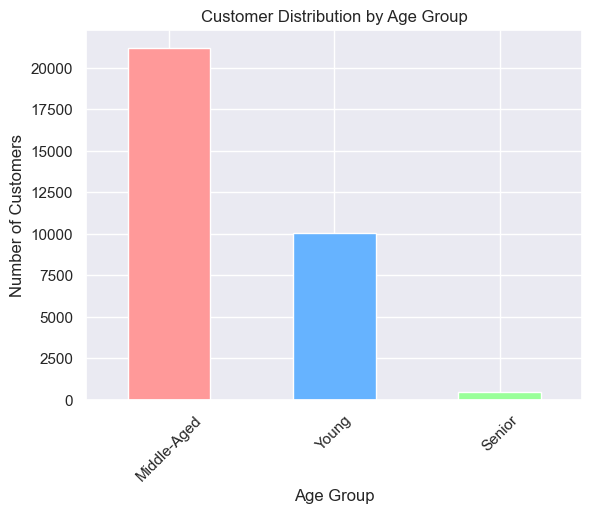

In [381]:
import matplotlib.pyplot as plt

# Calculate the number of customers in each age group
age_group_counts = df['age_group'].value_counts()

# Plot a bar chart for age group distribution
age_group_counts.plot(kind='bar', color=['#ff9999','#66b3ff','#99ff99','#ffcc99','#c2c2f0'])
plt.xlabel('Age Group')
plt.ylabel('Number of Customers')
plt.title('Customer Distribution by Age Group')
plt.xticks(rotation=45)
plt.show()


In [382]:
# Define frequency segments
df['frequency_segment'] = pd.cut(df['order_frequency'], bins=[-23, 10, 30, 50],
                                   labels=['Infrequent', 'Occasional', 'Frequent'], right=True)

# Verify the results
df[['order_frequency','frequency_segment']].head()

,order_frequency,frequency_segment
0,1.0,Infrequent
1,1.0,Infrequent
2,1.0,Infrequent
3,2.0,Infrequent
4,2.0,Infrequent


In [383]:
df["frequency_segment"].isna().sum()
#df["order_frequency"].tail

17850

/var/folders/_s/_rkc5yf52mjg60_cwkkrw5yc0000gn/T/ipykernel_1354/2657258774.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  spending_by_id_time = df_long.groupby(['age_group', 'Time of Day'])['Spending'].sum().reset_index()


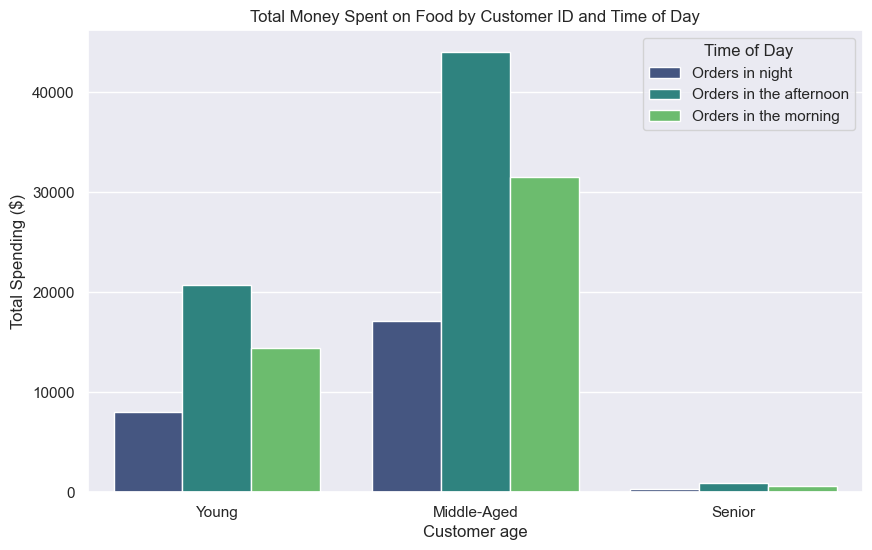

In [384]:
# Reshape the DataFrame to long format using customer_id
df_long = df.melt(id_vars='age_group', value_vars=['Orders in the morning', 'Orders in the afternoon', 'Orders in night'],
                  var_name='Time of Day', value_name='Spending')

# Group by customer_id and Time of Day, summing the spending
spending_by_id_time = df_long.groupby(['age_group', 'Time of Day'])['Spending'].sum().reset_index()

# Plotting
plt.figure(figsize=(10, 6))
sns.barplot(x='age_group', y='Spending', hue='Time of Day', data=spending_by_id_time, palette='viridis')

# Adding title and labels
plt.title("Total Money Spent on Food by Customer ID and Time of Day")
plt.xlabel("Customer age")
plt.ylabel("Total Spending ($)")
plt.legend(title="Time of Day")
plt.show()

/var/folders/_s/_rkc5yf52mjg60_cwkkrw5yc0000gn/T/ipykernel_1354/244341936.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  orders_by_age_group = df.groupby('age_group')[['Orders on week', 'Orders on Weekend']].sum().reset_index()


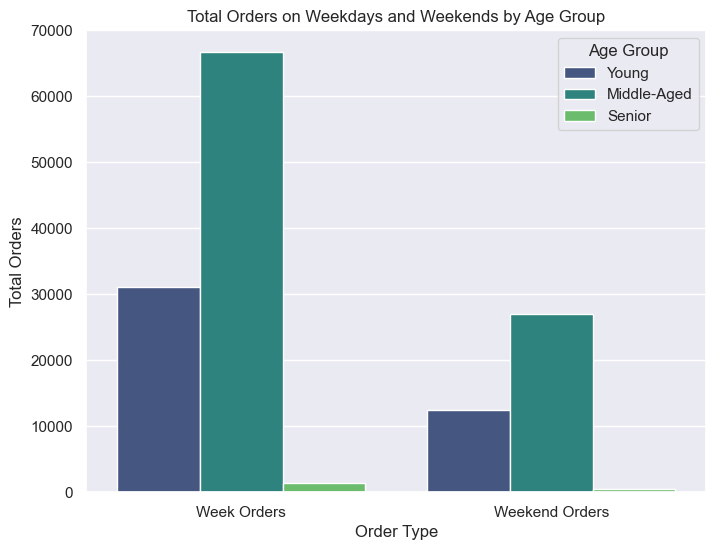

In [385]:
# Group by age_group and sum the orders
orders_by_age_group = df.groupby('age_group')[['Orders on week', 'Orders on Weekend']].sum().reset_index()

# Reshape the DataFrame to long format
orders_long = orders_by_age_group.melt(id_vars='age_group',
                                        value_vars=['Orders on week', 'Orders on Weekend'],
                                        var_name='Order Type', value_name='Total Orders')

# Optional: Adjusting Order Type names (if needed, otherwise can be omitted)
orders_long['Order Type'] = orders_long['Order Type'].replace({
    'Orders on week': 'Week Orders',
    'Orders on Weekend': 'Weekend Orders'
})

# Plotting
plt.figure(figsize=(8, 6))
sns.barplot(x='Order Type', y='Total Orders', hue='age_group', data=orders_long, palette='viridis')

# Adding title and labels
plt.title("Total Orders on Weekdays and Weekends by Age Group")
plt.xlabel("Order Type")
plt.ylabel("Total Orders")
plt.legend(title="Age Group")
plt.show()

/var/folders/_s/_rkc5yf52mjg60_cwkkrw5yc0000gn/T/ipykernel_1354/451369953.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_frequency = df.groupby(['age_group', 'frequency_segment']).size().unstack()


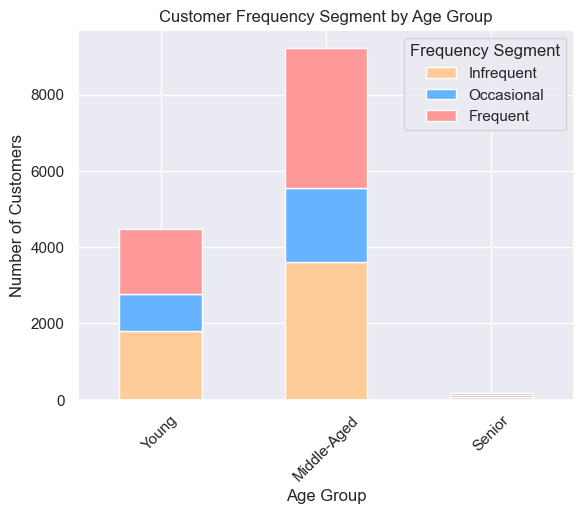

In [386]:
# Count the number of customers in each age group and frequency segment
age_frequency = df.groupby(['age_group', 'frequency_segment']).size().unstack()

# Plot a stacked bar chart
age_frequency.plot(kind='bar', stacked=True, color=['#ffcc99', '#66b3ff', '#ff9999'])
plt.xlabel('Age Group')
plt.ylabel('Number of Customers')
plt.title('Customer Frequency Segment by Age Group')
plt.legend(title='Frequency Segment')
plt.xticks(rotation=45)
plt.show()


In [387]:
df.columns

Index(['customer_id', 'customer_region', 'customer_age', 'vendor_count',
       'product_count', 'is_chain', 'first_order', 'last_order', 'last_promo',
       'payment_method', 'CUI_American', 'CUI_Asian', 'CUI_Beverages',
       'CUI_Cafe', 'CUI_Chicken Dishes', 'CUI_Chinese', 'CUI_Desserts',
       'CUI_Healthy', 'CUI_Indian', 'CUI_Italian', 'CUI_Japanese',
       'CUI_Noodle Dishes', 'CUI_OTHER', 'CUI_Street Food / Snacks',
       'CUI_Thai', 'DOW_0', 'DOW_1', 'DOW_2', 'DOW_3', 'DOW_4', 'DOW_5',
       'DOW_6', 'HR_0', 'HR_1', 'HR_2', 'HR_3', 'HR_4', 'HR_5', 'HR_6', 'HR_7',
       'HR_8', 'HR_9', 'HR_10', 'HR_11', 'HR_12', 'HR_13', 'HR_14', 'HR_15',
       'HR_16', 'HR_17', 'HR_18', 'HR_19', 'HR_20', 'HR_21', 'HR_22', 'HR_23',
       'total orders', 'Orders on Weekend', 'Orders on week',
       'Orders in the morning', 'Orders in the afternoon', 'Orders in night',
       'American Cuisine', 'Asian Cuisine', 'European Cuisine',
       'Snacks & Beverages', 'Other Cuisine', 'total_amo

/var/folders/_s/_rkc5yf52mjg60_cwkkrw5yc0000gn/T/ipykernel_1354/4093965150.py:2: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  age_region_pivot = pd.pivot_table(df, index='age_group', columns='payment_method', aggfunc='size', fill_value=0)


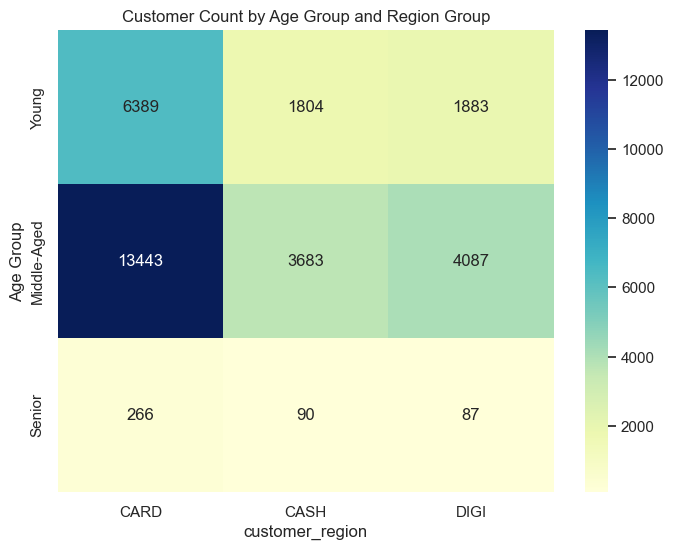

In [388]:
# Create a pivot table to count customers by age group and region group
age_region_pivot = pd.pivot_table(df, index='age_group', columns='payment_method', aggfunc='size', fill_value=0)

# Plot a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(age_region_pivot, annot=True, cmap='YlGnBu', fmt='d')
plt.xlabel('customer_region')
plt.ylabel('Age Group')
plt.title('Customer Count by Age Group and Region Group')
plt.show()


/var/folders/_s/_rkc5yf52mjg60_cwkkrw5yc0000gn/T/ipykernel_1354/2825785860.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=payment_counts.index, y=payment_counts.values, palette="viridis")


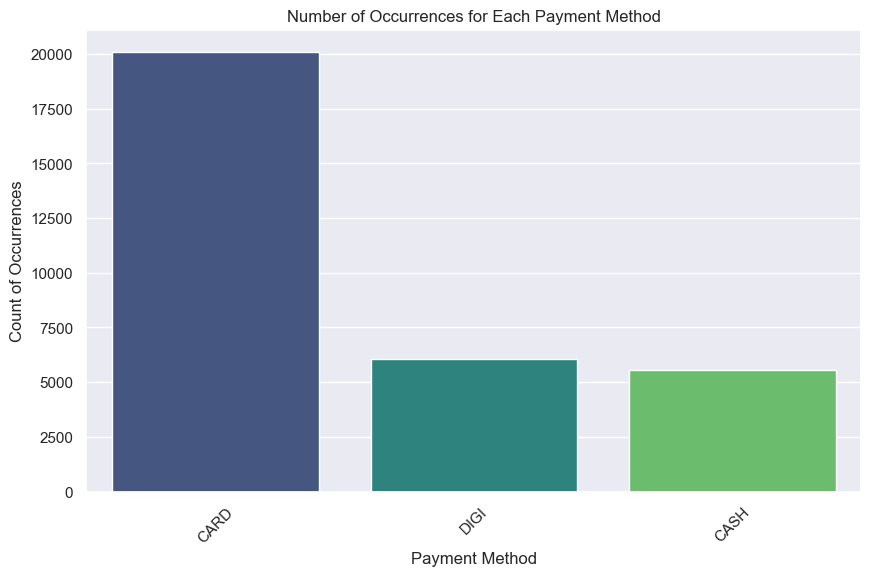

In [389]:
# Calculate the count of each payment method
payment_counts = df['payment_method'].value_counts()

# Plotting the bar chart for payment method occurrences
plt.figure(figsize=(10, 6))
sns.barplot(x=payment_counts.index, y=payment_counts.values, palette="viridis")
plt.xlabel('Payment Method')
plt.ylabel('Count of Occurrences')
plt.title('Number of Occurrences for Each Payment Method')
plt.xticks(rotation=45)
plt.show()

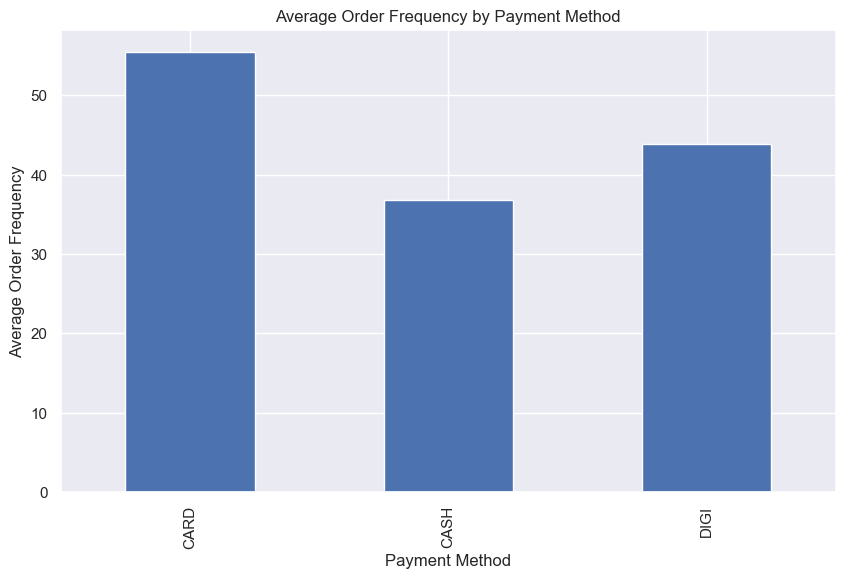

In [390]:
# 2. Payment method with average order frequency
plt.figure(figsize=(10, 6))
df.groupby('payment_method')['order_frequency'].mean().plot(kind='bar')
plt.title('Average Order Frequency by Payment Method')
plt.xlabel('Payment Method')
plt.ylabel('Average Order Frequency')
plt.show()

<Figure size 1000x600 with 0 Axes>

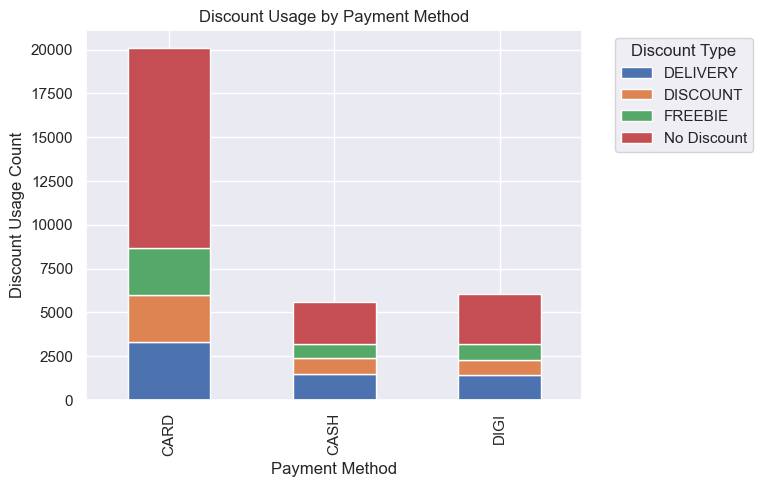

In [391]:
# Ensure column names are consistent and correct
df['last_promo'] = df['last_promo'].replace(['-'], 'No Discount').fillna('No Discount')

# Set up plotting for discount usage by payment method
discount_column = 'last_promo'  # Reflects discount usage
plt.figure(figsize=(10, 6))
df.groupby('payment_method')[discount_column].value_counts().unstack().plot(kind='bar', stacked=True)
plt.title('Discount Usage by Payment Method')
plt.xlabel('Payment Method')
plt.ylabel('Discount Usage Count')
plt.legend(title='Discount Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()


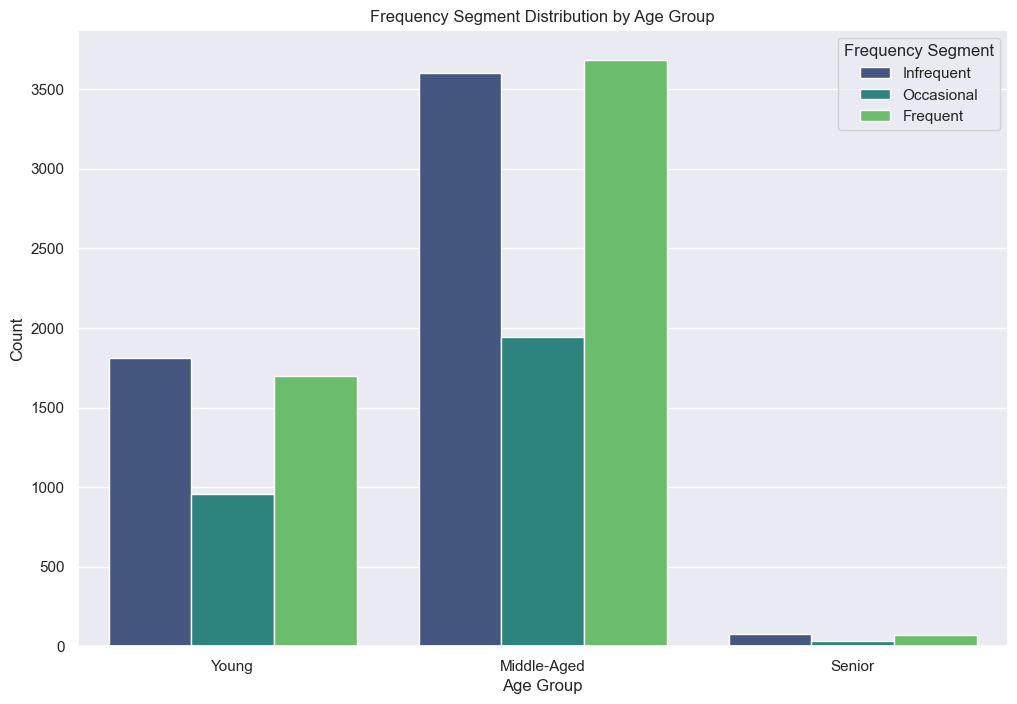

In [392]:
plt.figure(figsize=(12, 8))
# Countplot with hue for frequency segments
sns.countplot(data=df, x='age_group', hue='frequency_segment', palette="viridis")
plt.title('Frequency Segment Distribution by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Count')
plt.legend(title='Frequency Segment')
plt.show()

In [393]:
df.columns.tolist()

['customer_id',
 'customer_region',
 'customer_age',
 'vendor_count',
 'product_count',
 'is_chain',
 'first_order',
 'last_order',
 'last_promo',
 'payment_method',
 'CUI_American',
 'CUI_Asian',
 'CUI_Beverages',
 'CUI_Cafe',
 'CUI_Chicken Dishes',
 'CUI_Chinese',
 'CUI_Desserts',
 'CUI_Healthy',
 'CUI_Indian',
 'CUI_Italian',
 'CUI_Japanese',
 'CUI_Noodle Dishes',
 'CUI_OTHER',
 'CUI_Street Food / Snacks',
 'CUI_Thai',
 'DOW_0',
 'DOW_1',
 'DOW_2',
 'DOW_3',
 'DOW_4',
 'DOW_5',
 'DOW_6',
 'HR_0',
 'HR_1',
 'HR_2',
 'HR_3',
 'HR_4',
 'HR_5',
 'HR_6',
 'HR_7',
 'HR_8',
 'HR_9',
 'HR_10',
 'HR_11',
 'HR_12',
 'HR_13',
 'HR_14',
 'HR_15',
 'HR_16',
 'HR_17',
 'HR_18',
 'HR_19',
 'HR_20',
 'HR_21',
 'HR_22',
 'HR_23',
 'total orders',
 'Orders on Weekend',
 'Orders on week',
 'Orders in the morning',
 'Orders in the afternoon',
 'Orders in night',
 'American Cuisine',
 'Asian Cuisine',
 'European Cuisine',
 'Snacks & Beverages',
 'Other Cuisine',
 'total_amount_spent',
 'order_frequency'

In [394]:
df = df.drop(columns=[
    'DOW_0', 'DOW_1', 'DOW_2', 'DOW_3', 'DOW_4', 'DOW_5', 'DOW_6',
    'HR_0', 'HR_1', 'HR_2', 'HR_3', 'HR_4', 'HR_5', 'HR_6', 'HR_7',
    'HR_8', 'HR_9', 'HR_10', 'HR_11', 'HR_12', 'HR_13', 'HR_14',
    'HR_15', 'HR_16', 'HR_17', 'HR_18', 'HR_19', 'HR_20', 'HR_21',
    'HR_22', 'HR_23',
    'CUI_American', 'CUI_Asian', 'CUI_Beverages', 'CUI_Cafe',
    'CUI_Chicken Dishes', 'CUI_Chinese', 'CUI_Desserts', 'CUI_Healthy',
    'CUI_Indian', 'CUI_Italian', 'CUI_Japanese', 'CUI_Noodle Dishes',
    'CUI_OTHER', 'CUI_Street Food / Snacks', 'CUI_Thai',
    'customer_region', 'customer_age', 'first_order', 'last_order'
])


In [395]:
df.columns.tolist()

['customer_id',
 'vendor_count',
 'product_count',
 'is_chain',
 'last_promo',
 'payment_method',
 'total orders',
 'Orders on Weekend',
 'Orders on week',
 'Orders in the morning',
 'Orders in the afternoon',
 'Orders in night',
 'American Cuisine',
 'Asian Cuisine',
 'European Cuisine',
 'Snacks & Beverages',
 'Other Cuisine',
 'total_amount_spent',
 'order_frequency',
 'age_group',
 'frequency_segment']

In [396]:
metric_features_updated = [
    'vendor_count', 'product_count', 'Orders on Weekend', 'Orders on week',
    'Orders in the morning', 'Orders in the afternoon', 'Orders in night',
    'American Cuisine', 'Asian Cuisine', 'European Cuisine',
    'Snacks & Beverages', 'Other Cuisine', 'order_frequency'
]

non_metric_features_updated = [
    'customer_id', 'is_chain', 'last_promo', 'payment_method',
    'age_group', 'frequency_segment'
]

metric_features_updated, non_metric_features_updated


(['vendor_count',
  'product_count',
  'Orders on Weekend',
  'Orders on week',
  'Orders in the morning',
  'Orders in the afternoon',
  'Orders in night',
  'American Cuisine',
  'Asian Cuisine',
  'European Cuisine',
  'Snacks & Beverages',
  'Other Cuisine',
  'order_frequency'],
 ['customer_id',
  'is_chain',
  'last_promo',
  'payment_method',
  'age_group',
  'frequency_segment'])

In [397]:
df.columns

Index(['customer_id', 'vendor_count', 'product_count', 'is_chain',
       'last_promo', 'payment_method', 'total orders', 'Orders on Weekend',
       'Orders on week', 'Orders in the morning', 'Orders in the afternoon',
       'Orders in night', 'American Cuisine', 'Asian Cuisine',
       'European Cuisine', 'Snacks & Beverages', 'Other Cuisine',
       'total_amount_spent', 'order_frequency', 'age_group',
       'frequency_segment'],
      dtype='object')

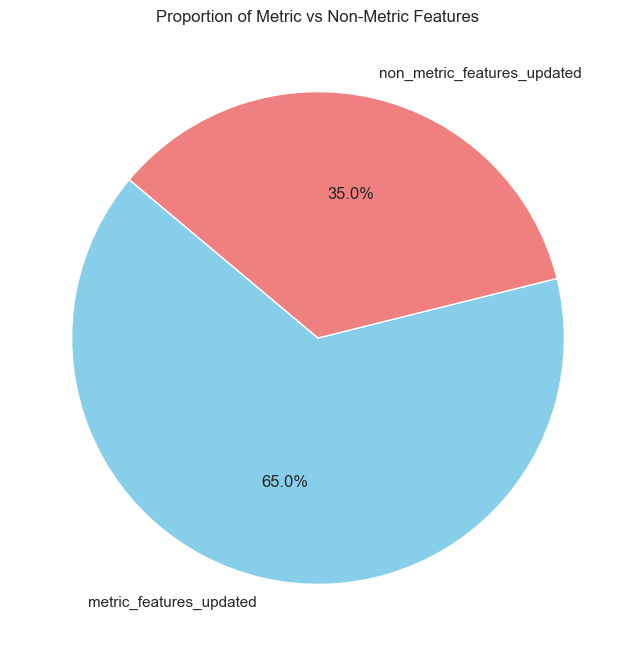

In [398]:
metric_features_updated = [
    'vendor_count', 'product_count', 'Orders on Weekend', 'Orders on week',
    'Orders in the morning', 'Orders in the afternoon', 'Orders in night',
    'American Cuisine', 'Asian Cuisine', 'European Cuisine',
    'Snacks & Beverages', 'Other Cuisine', 'order_frequency'
]

non_metric_features_updated = [
    'customer_id_hashed', 'is_chain', 'last_promo', 'payment_method',
    'age_group', 'frequency_segment', 'region_group'
]

metric_features_updated, non_metric_features_updated



# Count the number of metric and non-metric features
feature_counts = {'metric_features_updated': len(metric_features_updated), 'non_metric_features_updated': len(non_metric_features_updated)}
# Plotting a pie chart to display the proportion of metric and non-metric features
plt.figure(figsize=(8, 8))
plt.pie(feature_counts.values(), labels=feature_counts.keys(), autopct='%1.1f%%',
        startangle=140, colors=['skyblue', 'lightcoral'])
plt.title('Proportion of Metric vs Non-Metric Features')
plt.show()

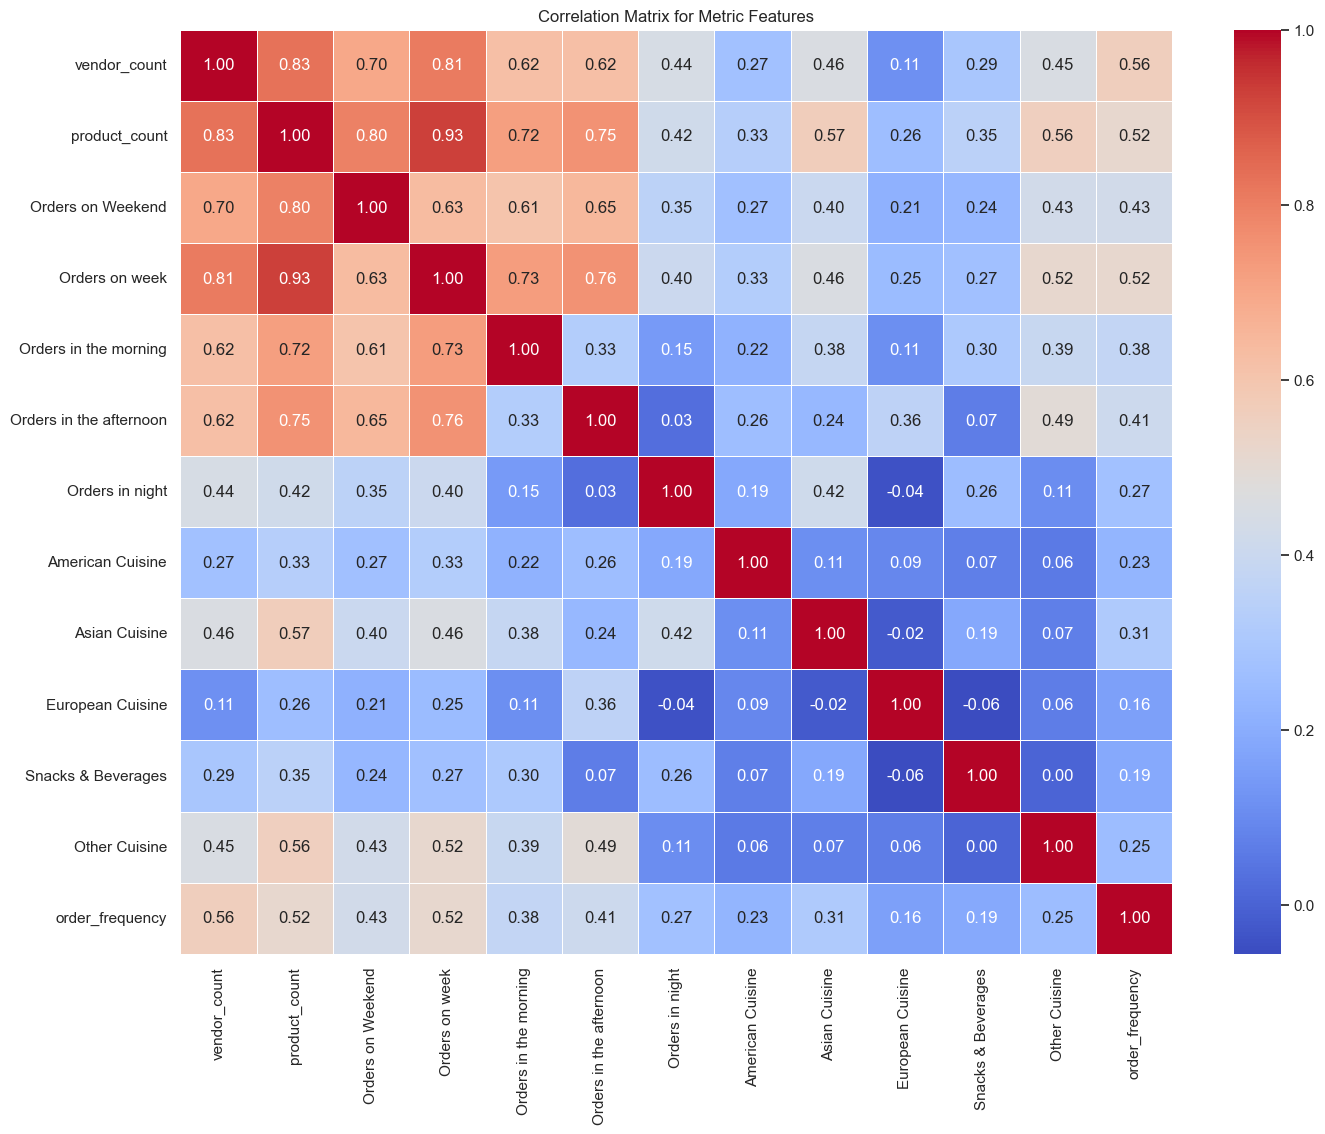

In [399]:
# Correlation heatmap for metric features
correlation_matrix = df[metric_features_updated].corr()

# Plotting the correlation matrix
plt.figure(figsize=(16, 12))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Matrix for Metric Features')
plt.show()

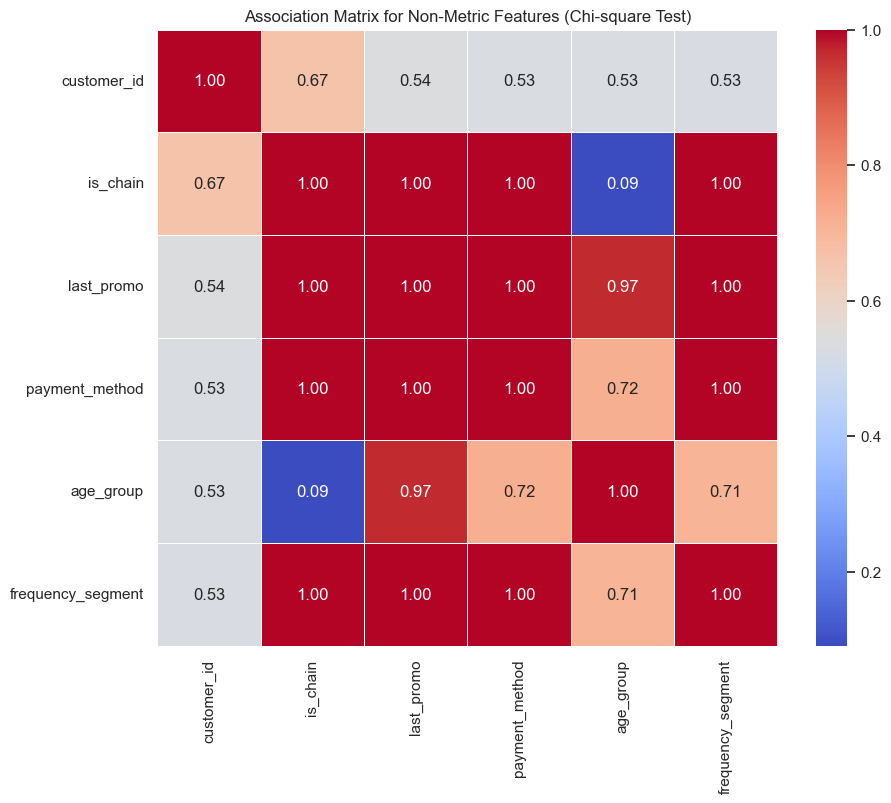

In [400]:
from scipy.stats import chi2_contingency

# List of non-metric features to analyze
non_metric_features = ['customer_id', 'is_chain', 'last_promo', 'payment_method',
                       'age_group', 'frequency_segment']

# Initialize an empty DataFrame to store Chi-square test results
chi2_results = pd.DataFrame(index=non_metric_features, columns=non_metric_features, dtype=float)

# Perform the Chi-square test for each pair of non-metric features
for feature1 in non_metric_features:
    for feature2 in non_metric_features:
        if feature1 == feature2:
            chi2_results.loc[feature1, feature2] = 1.0  # Perfect correlation with itself
        else:
            # Create a contingency table
            contingency_table = pd.crosstab(df[feature1], df[feature2])

            # Skip pairs with empty contingency tables
            if contingency_table.empty:
                chi2_results.loc[feature1, feature2] = None
            else:
                # Perform the Chi-square test
                chi2, p_value, _, _ = chi2_contingency(contingency_table)
                # Store the p-value in the results DataFrame
                chi2_results.loc[feature1, feature2] = 1 - p_value  # Use (1 - p_value) to represent strength of association

# Replace NaNs with an indication (e.g., 0 or another placeholder) in the matrix
chi2_results = chi2_results.fillna(0)

# Plotting the heatmap for non-metric features
plt.figure(figsize=(10, 8))
sns.heatmap(chi2_results, annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)
plt.title('Association Matrix for Non-Metric Features (Chi-square Test)')
plt.show()

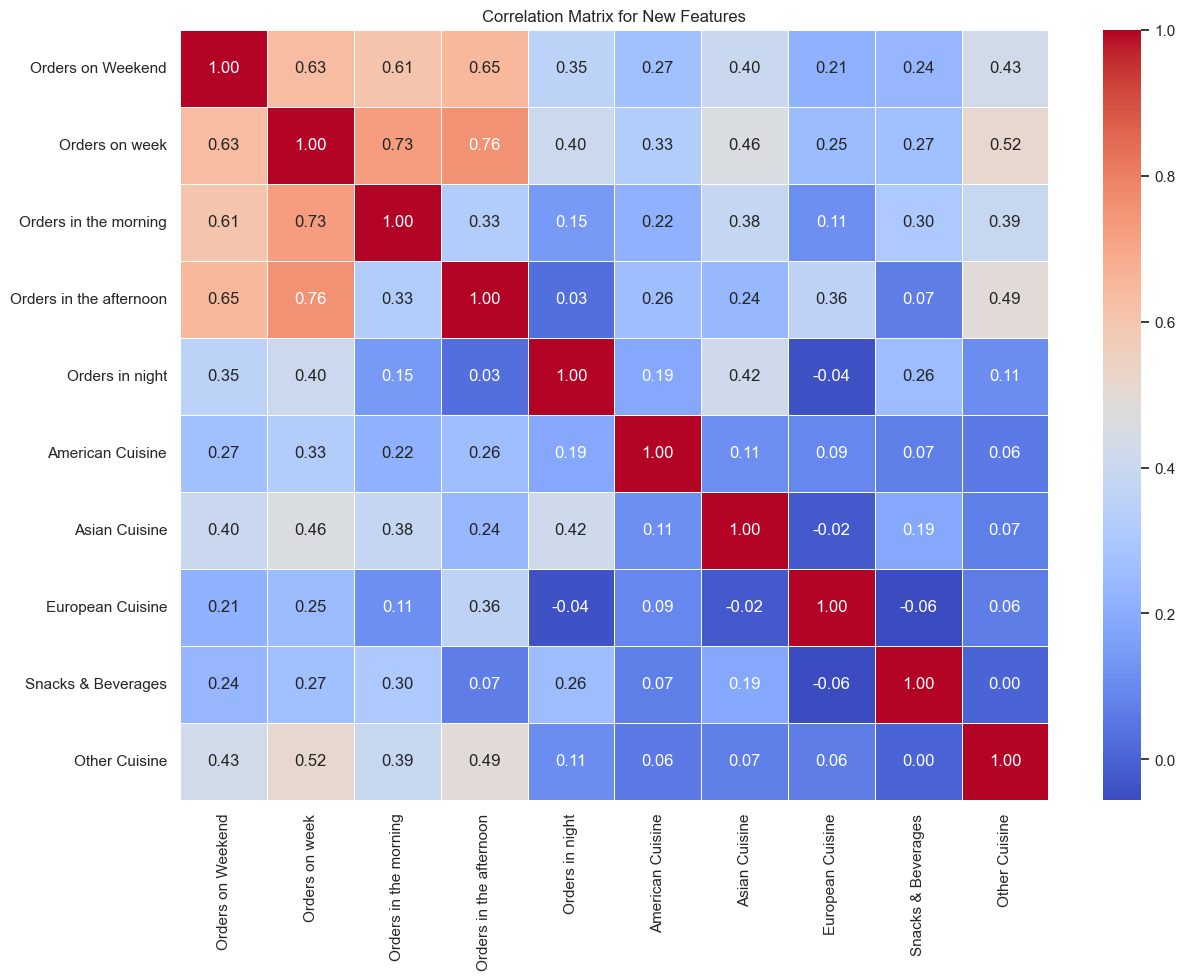

In [401]:
# Selecting the specified new features for the correlation analysis
selected_features = [
    'Orders on Weekend', 'Orders on week', 'Orders in the morning',
    'Orders in the afternoon', 'Orders in night', 'American Cuisine',
    'Asian Cuisine', 'European Cuisine', 'Snacks & Beverages',
    'Other Cuisine'
]

# Calculating the correlation matrix for the selected features
correlation_matrix_selected = df[selected_features].corr()

# Plotting the correlation matrix for the selected features
plt.figure(figsize=(14, 10))
sns.heatmap(correlation_matrix_selected, annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Matrix for New Features')
plt.show()

In [402]:
df["American_ratio"] = df["American Cuisine"] / df["total_amount_spent"]
df["Asian_ratio"] = df["Asian Cuisine"] / df["total_amount_spent"]
df["European_ratio"] = df["European Cuisine"] / df["total_amount_spent"]
df["Snacks_Beverages_ratio"] = df["Snacks & Beverages"] / df["total_amount_spent"]
df["Other_Cuisine_ratio"] = df["Other Cuisine"] / df["total_amount_spent"]

In [403]:
df["avg_vendor_use"] = df["vendor_count"] / df["product_count"]

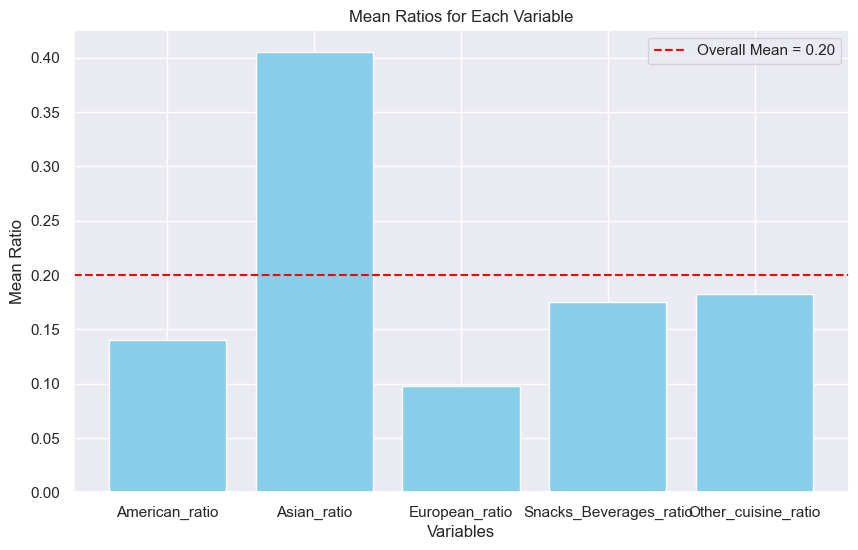

In [404]:
mean_values = {
    'American_ratio': np.mean(df["American_ratio"]),
    'Asian_ratio': np.mean(df["Asian_ratio"]),
    'European_ratio': np.mean(df["European_ratio"]),
    'Snacks_Beverages_ratio':np.mean(df["Snacks_Beverages_ratio"]),
    'Other_cuisine_ratio' : np.mean(df["Other_Cuisine_ratio"])
}

# Extract variables and their means for plotting
variables = list(mean_values.keys())
mean_ratios = list(mean_values.values())

# Plotting
plt.figure(figsize=(10, 6))
plt.bar(variables, mean_ratios, color='skyblue')

# Adding overall mean line
overall_mean = np.mean(mean_ratios)
plt.axhline(overall_mean, color='red', linestyle='--', label=f'Overall Mean = {overall_mean:.2f}')

# Adding labels and title
plt.xlabel('Variables')
plt.ylabel('Mean Ratio')
plt.title('Mean Ratios for Each Variable')
plt.legend()

plt.show()


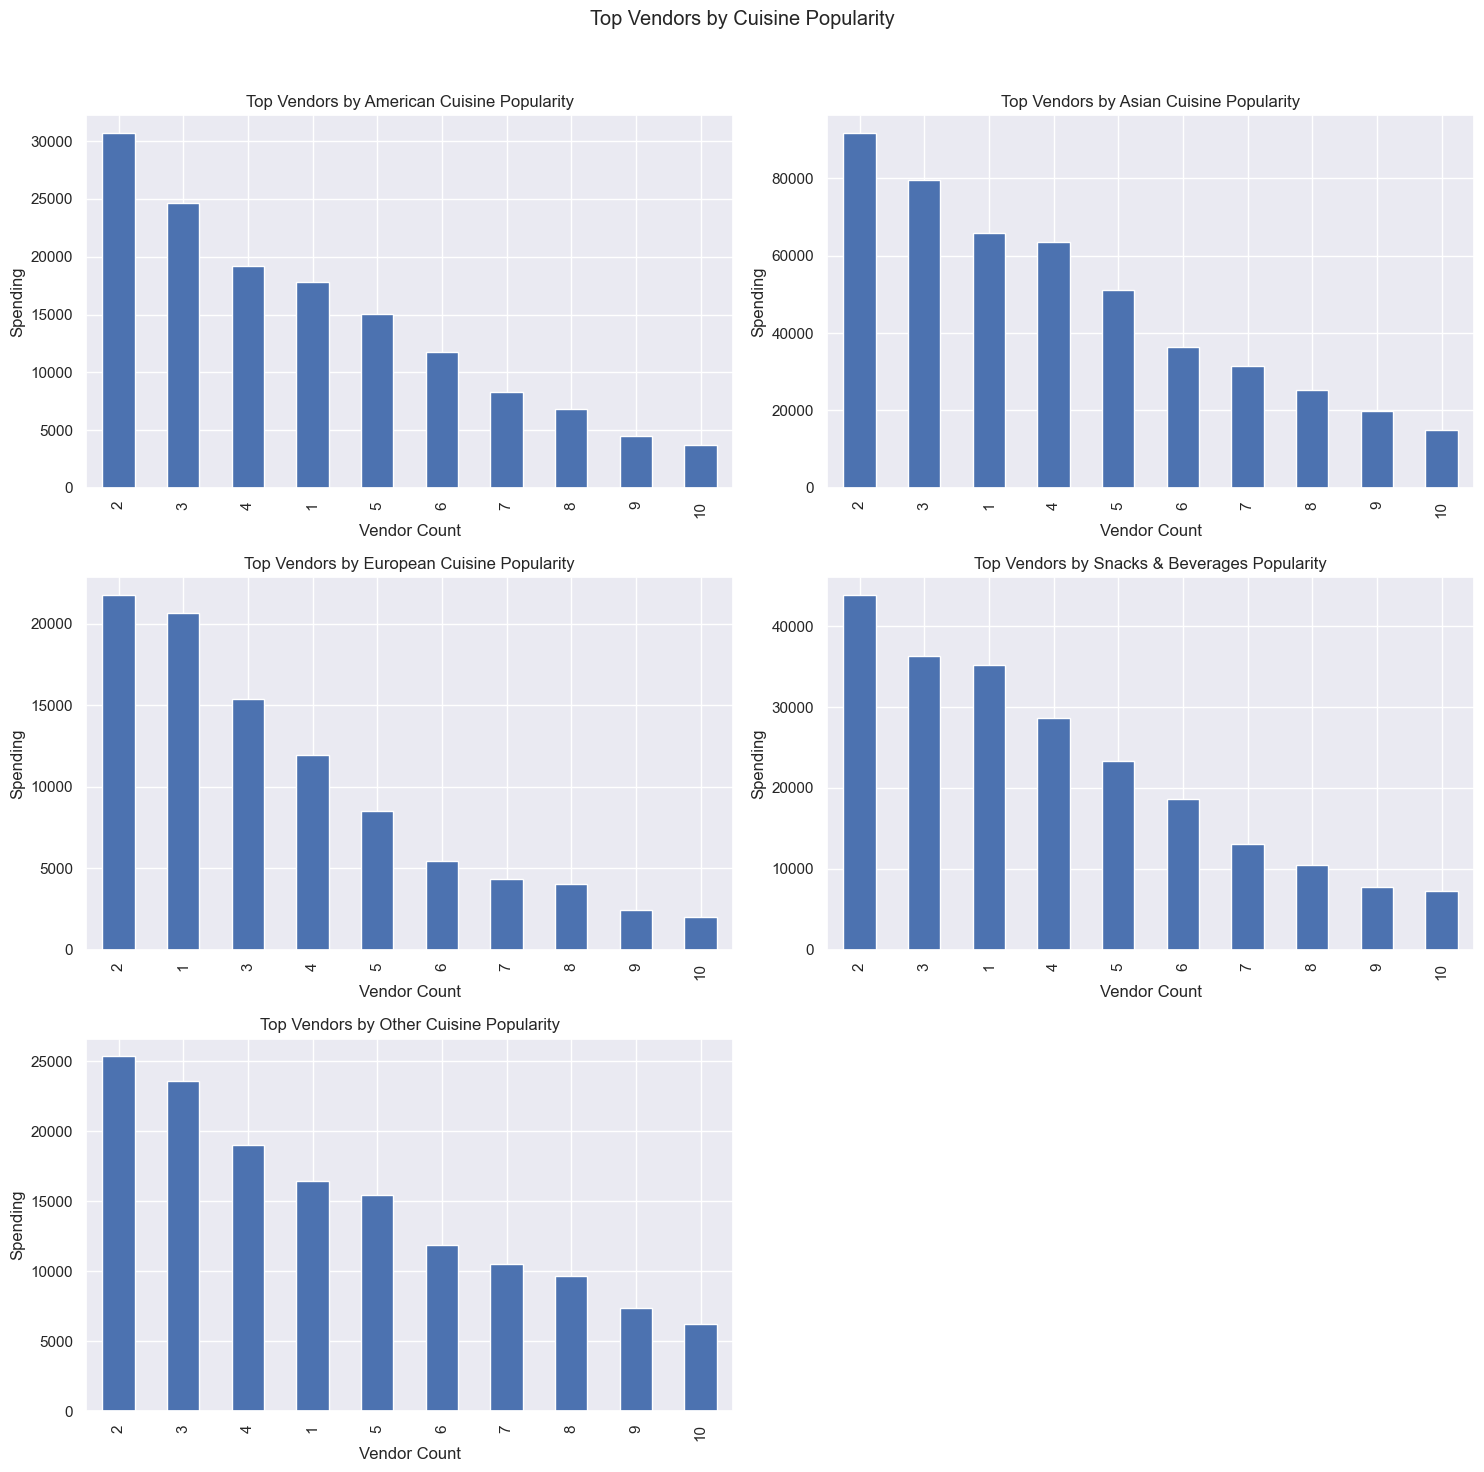

In [405]:
# Re-define the vendor_cuisine_popularity from the previous computation
vendor_cuisine_popularity = df.groupby('vendor_count')[
    ["American Cuisine", "Asian Cuisine", "European Cuisine", "Snacks & Beverages", "Other Cuisine"]
].sum()

# Plotting the top vendors by cuisine popularity
fig, axs = plt.subplots(3, 2, figsize=(15, 15))
fig.suptitle('Top Vendors by Cuisine Popularity')

# Define cuisines and plot titles
cuisines = ["American Cuisine", "Asian Cuisine", "European Cuisine", "Snacks & Beverages", "Other Cuisine"]
titles = ["American Cuisine", "Asian Cuisine", "European Cuisine", "Snacks & Beverages", "Other Cuisine"]

# Plot each cuisine
for i, (cuisine, title) in enumerate(zip(cuisines, titles)):
    ax = axs[i // 2, i % 2]  # Selecting subplot
    vendor_cuisine_popularity[cuisine].nlargest(10).plot(kind='bar', ax=ax)
    ax.set_title(f'Top Vendors by {title} Popularity')
    ax.set_xlabel('Vendor Count')
    ax.set_ylabel('Spending')

# Hide the last empty subplot
axs[2, 1].axis('off')

plt.tight_layout(rect=[0, 0, 1, 0.96])  # Adjust layout to fit title
plt.show()


In [406]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 31732 entries, 0 to 31887
Data columns (total 27 columns):
 #   Column                   Non-Null Count  Dtype   
---  ------                   --------------  -----   
 0   customer_id              31732 non-null  object  
 1   vendor_count             31732 non-null  int64   
 2   product_count            31732 non-null  int64   
 3   is_chain                 31732 non-null  int64   
 4   last_promo               31732 non-null  object  
 5   payment_method           31732 non-null  object  
 6   total orders             31732 non-null  int64   
 7   Orders on Weekend        31732 non-null  int64   
 8   Orders on week           31732 non-null  int64   
 9   Orders in the morning    31732 non-null  int64   
 10  Orders in the afternoon  31732 non-null  int64   
 11  Orders in night          31732 non-null  int64   
 12  American Cuisine         31732 non-null  float64 
 13  Asian Cuisine            31732 non-null  float64 
 14  European Cu

## <span style="color:salmon"> Preprocess the data  </span>

<!-- #### <span style="color:salmon"> Find Outlier and work with them  </span>  -->

In [409]:
# make a copy of dataset
df_original = df.copy()

#### <span style="color:salmon"> 1. check missing values </span>

In [411]:
# Calculate null percentage for each column
null_percentage_per_column = (df_original.isnull().sum() / len(df_original)) * 100

# Calculate total null percentage for the dataset
total_null_percentage = (df_original.isnull().sum().sum() / df_original.size) * 100

# Display results
print("Null Percentage per Column:\n", null_percentage_per_column)
print("Total Null Percentage in Dataset:", total_null_percentage)

Null Percentage per Column:
 customer_id                 0.000000
vendor_count                0.000000
product_count               0.000000
is_chain                    0.000000
last_promo                  0.000000
payment_method              0.000000
total orders                0.000000
Orders on Weekend           0.000000
Orders on week              0.000000
Orders in the morning       0.000000
Orders in the afternoon     0.000000
Orders in night             0.000000
American Cuisine            0.000000
Asian Cuisine               0.000000
European Cuisine            0.000000
Snacks & Beverages          0.000000
Other Cuisine               0.000000
total_amount_spent          0.000000
order_frequency             0.000000
age_group                   0.000000
frequency_segment          56.252364
American_ratio              0.000000
Asian_ratio                 0.000000
European_ratio              0.000000
Snacks_Beverages_ratio      0.000000
Other_Cuisine_ratio         0.000000
avg_vendo

#### <span style="color:salmon"> 1. check missing values </span>

In [413]:
# Add 'Unknown' to the categories
df_original['frequency_segment'] = df_original['frequency_segment'].cat.add_categories('Unknown')

# Fill missing values with 'Unknown'
df_original['frequency_segment'].fillna('Unknown', inplace=True)

/var/folders/_s/_rkc5yf52mjg60_cwkkrw5yc0000gn/T/ipykernel_1354/1928961676.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_original['frequency_segment'].fillna('Unknown', inplace=True)


#### <span style="color:salmon"> 2. seperate metric and non metric features </span>

In [415]:
# Separate metric (numerical) features
# metric_features = df_original.select_dtypes(include=['float64', 'int64']).columns.tolist()
metric_features = ['vendor_count',
 'product_count',
 'is_chain',
 'Orders on Weekend',
 'Orders on week',
 'Orders in the morning',
 'Orders in the afternoon',
 'Orders in night',
 'American Cuisine',
 'Asian Cuisine',
 'European Cuisine',
 'Snacks & Beverages',
 'Other Cuisine',
 'total_amount_spent',
 'order_frequency',
 'American_ratio',
 'Asian_ratio',
 'European_ratio',
 'Snacks_Beverages_ratio',
 'Other_Cuisine_ratio',
 'avg_vendor_use']
# Separate non-metric (categorical/non-numerical) features
non_metric_features = df_original.select_dtypes(exclude=['float64', 'int64']).columns.tolist()

# Display the lists
print("Metric Features:\n", metric_features)
print("Non-Metric Features:", non_metric_features)

Metric Features:
 ['vendor_count', 'product_count', 'is_chain', 'Orders on Weekend', 'Orders on week', 'Orders in the morning', 'Orders in the afternoon', 'Orders in night', 'American Cuisine', 'Asian Cuisine', 'European Cuisine', 'Snacks & Beverages', 'Other Cuisine', 'total_amount_spent', 'order_frequency', 'American_ratio', 'Asian_ratio', 'European_ratio', 'Snacks_Beverages_ratio', 'Other_Cuisine_ratio', 'avg_vendor_use']
Non-Metric Features: ['customer_id', 'last_promo', 'payment_method', 'age_group', 'frequency_segment']


In [416]:
df_original[metric_features].describe()

,vendor_count,product_count,is_chain,Orders on Weekend,Orders on week,Orders in the morning,Orders in the afternoon,Orders in night,American Cuisine,Asian Cuisine,...,Snacks & Beverages,Other Cuisine,total_amount_spent,order_frequency,American_ratio,Asian_ratio,European_ratio,Snacks_Beverages_ratio,Other_Cuisine_ratio,avg_vendor_use
count,31732.000000,31732.000000,31732.000000,31732.000000,31732.000000,31732.000000,31732.000000,31732.000000,31732.000000,31732.000000,...,31732.000000,31732.000000,31732.000000,31732.000000,31732.000000,31732.000000,31732.000000,31732.000000,31732.000000,31732.000000
mean,3.117295,5.696111,2.830361,1.266261,3.123472,1.471480,2.068921,0.800391,4.903913,16.941208,...,7.938243,5.455881,38.485399,49.974381,0.139955,0.405160,0.097667,0.175096,0.182123,0.693145
std,2.770356,6.962979,3.983752,1.776286,3.772268,2.547628,3.120848,1.608901,11.677447,29.460631,...,20.434290,13.699920,46.452160,29.694924,0.269193,0.392333,0.249424,0.308381,0.310509,0.258658
min,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.370000,-22.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.014286
25%,1.000000,2.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,13.030000,27.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.500000
50%,2.000000,3.000000,2.000000,1.000000,2.000000,1.000000,1.000000,0.000000,0.000000,7.120000,...,0.000000,0.000000,24.210000,57.000000,0.000000,0.329371,0.000000,0.000000,0.000000,0.666667
75%,4.000000,7.000000,3.000000,2.000000,4.000000,2.000000,3.000000,1.000000,5.720000,21.862500,...,6.360000,5.920000,45.242500,76.000000,0.158326,0.776339,0.000000,0.239924,0.276796,1.000000
max,41.000000,269.000000,83.000000,35.000000,67.000000,71.000000,62.000000,43.000000,280.210000,1003.430000,...,519.700000,366.080000,1418.330000,90.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [417]:
df = df_original.copy()

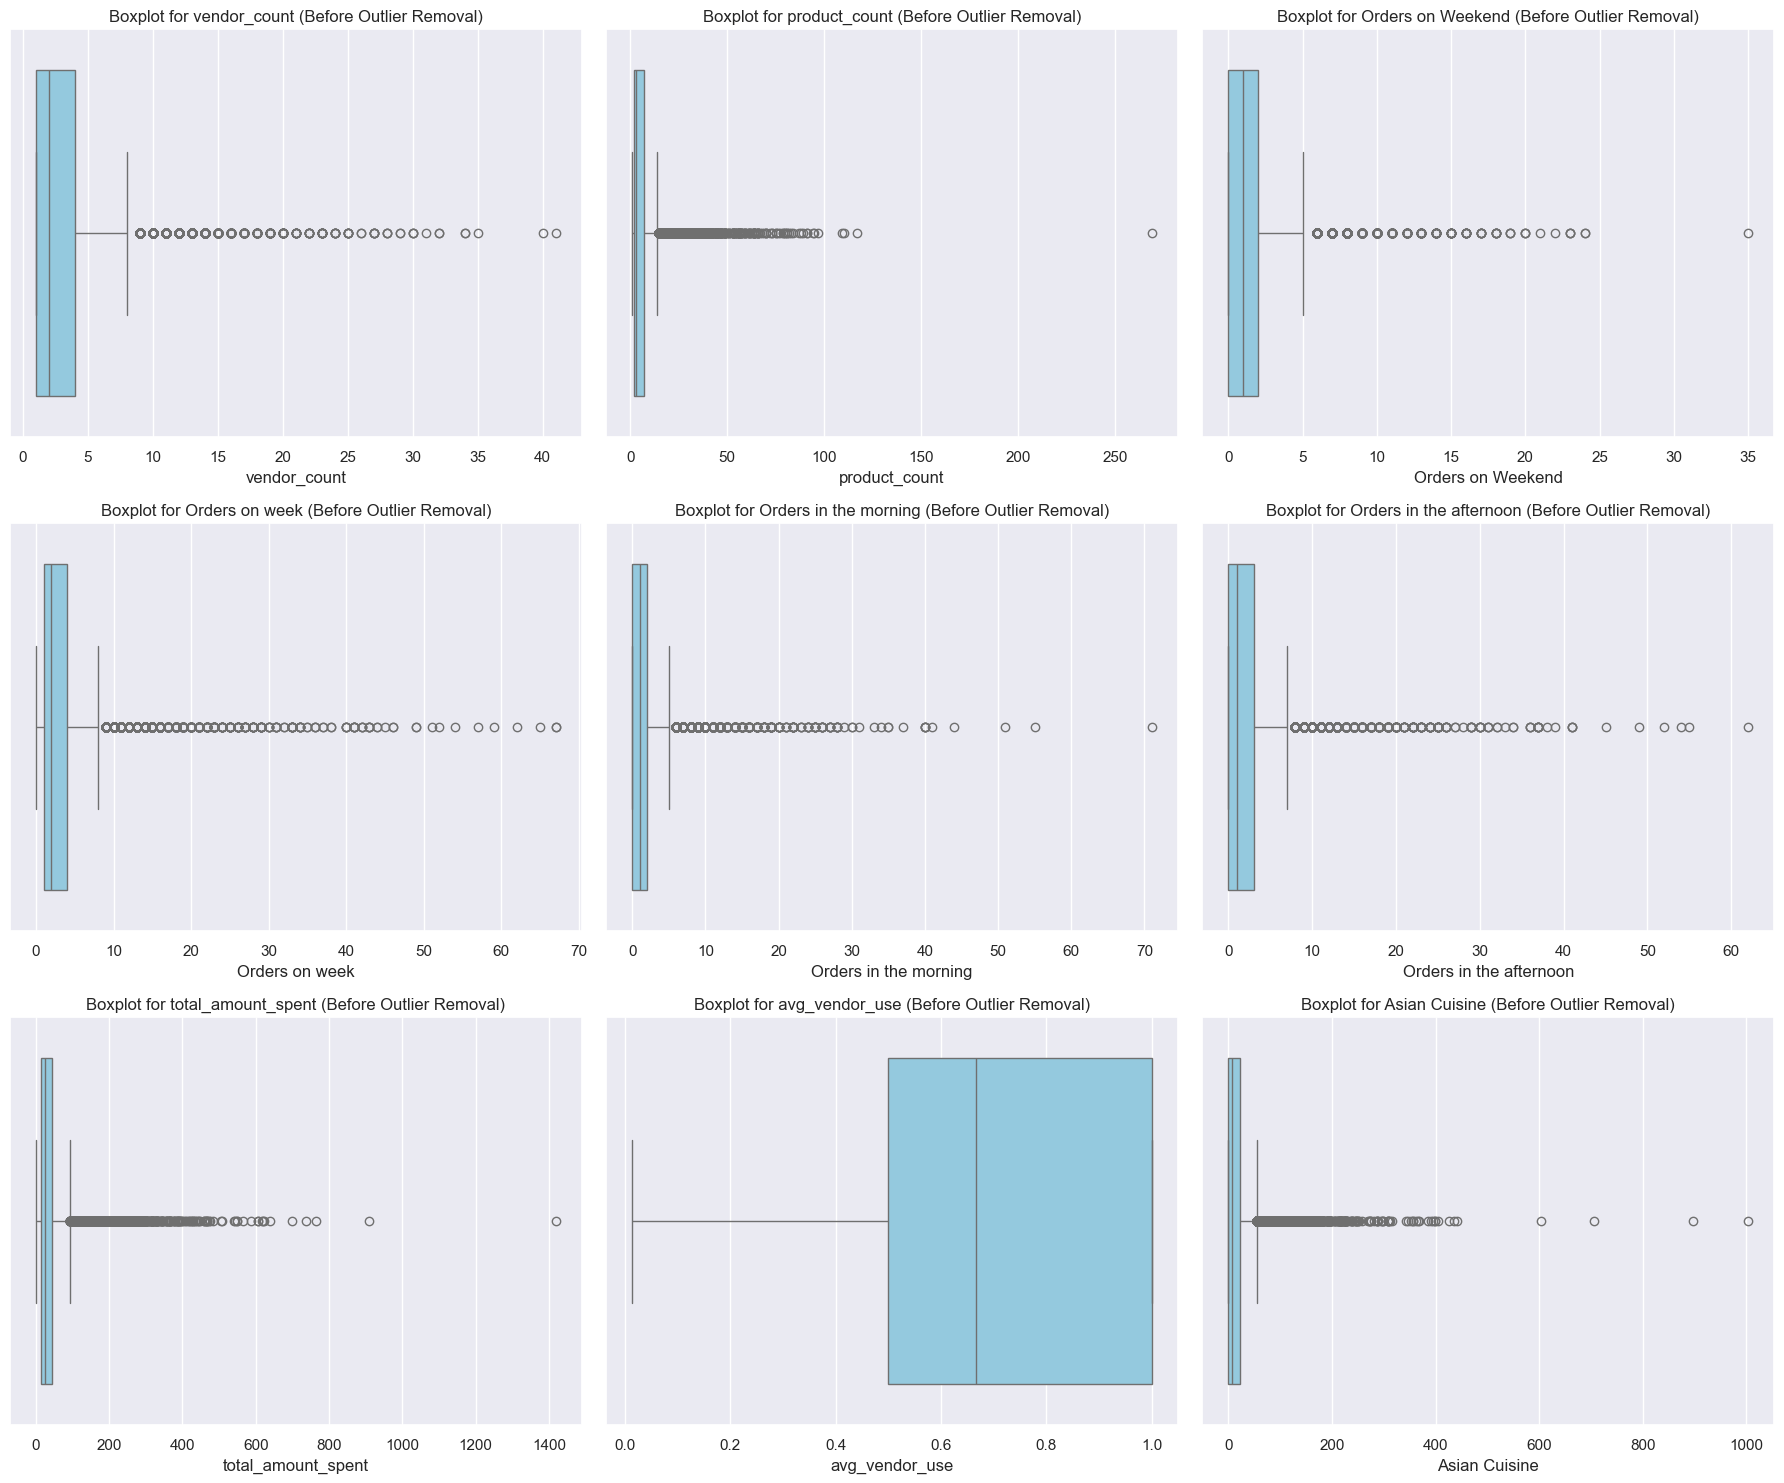

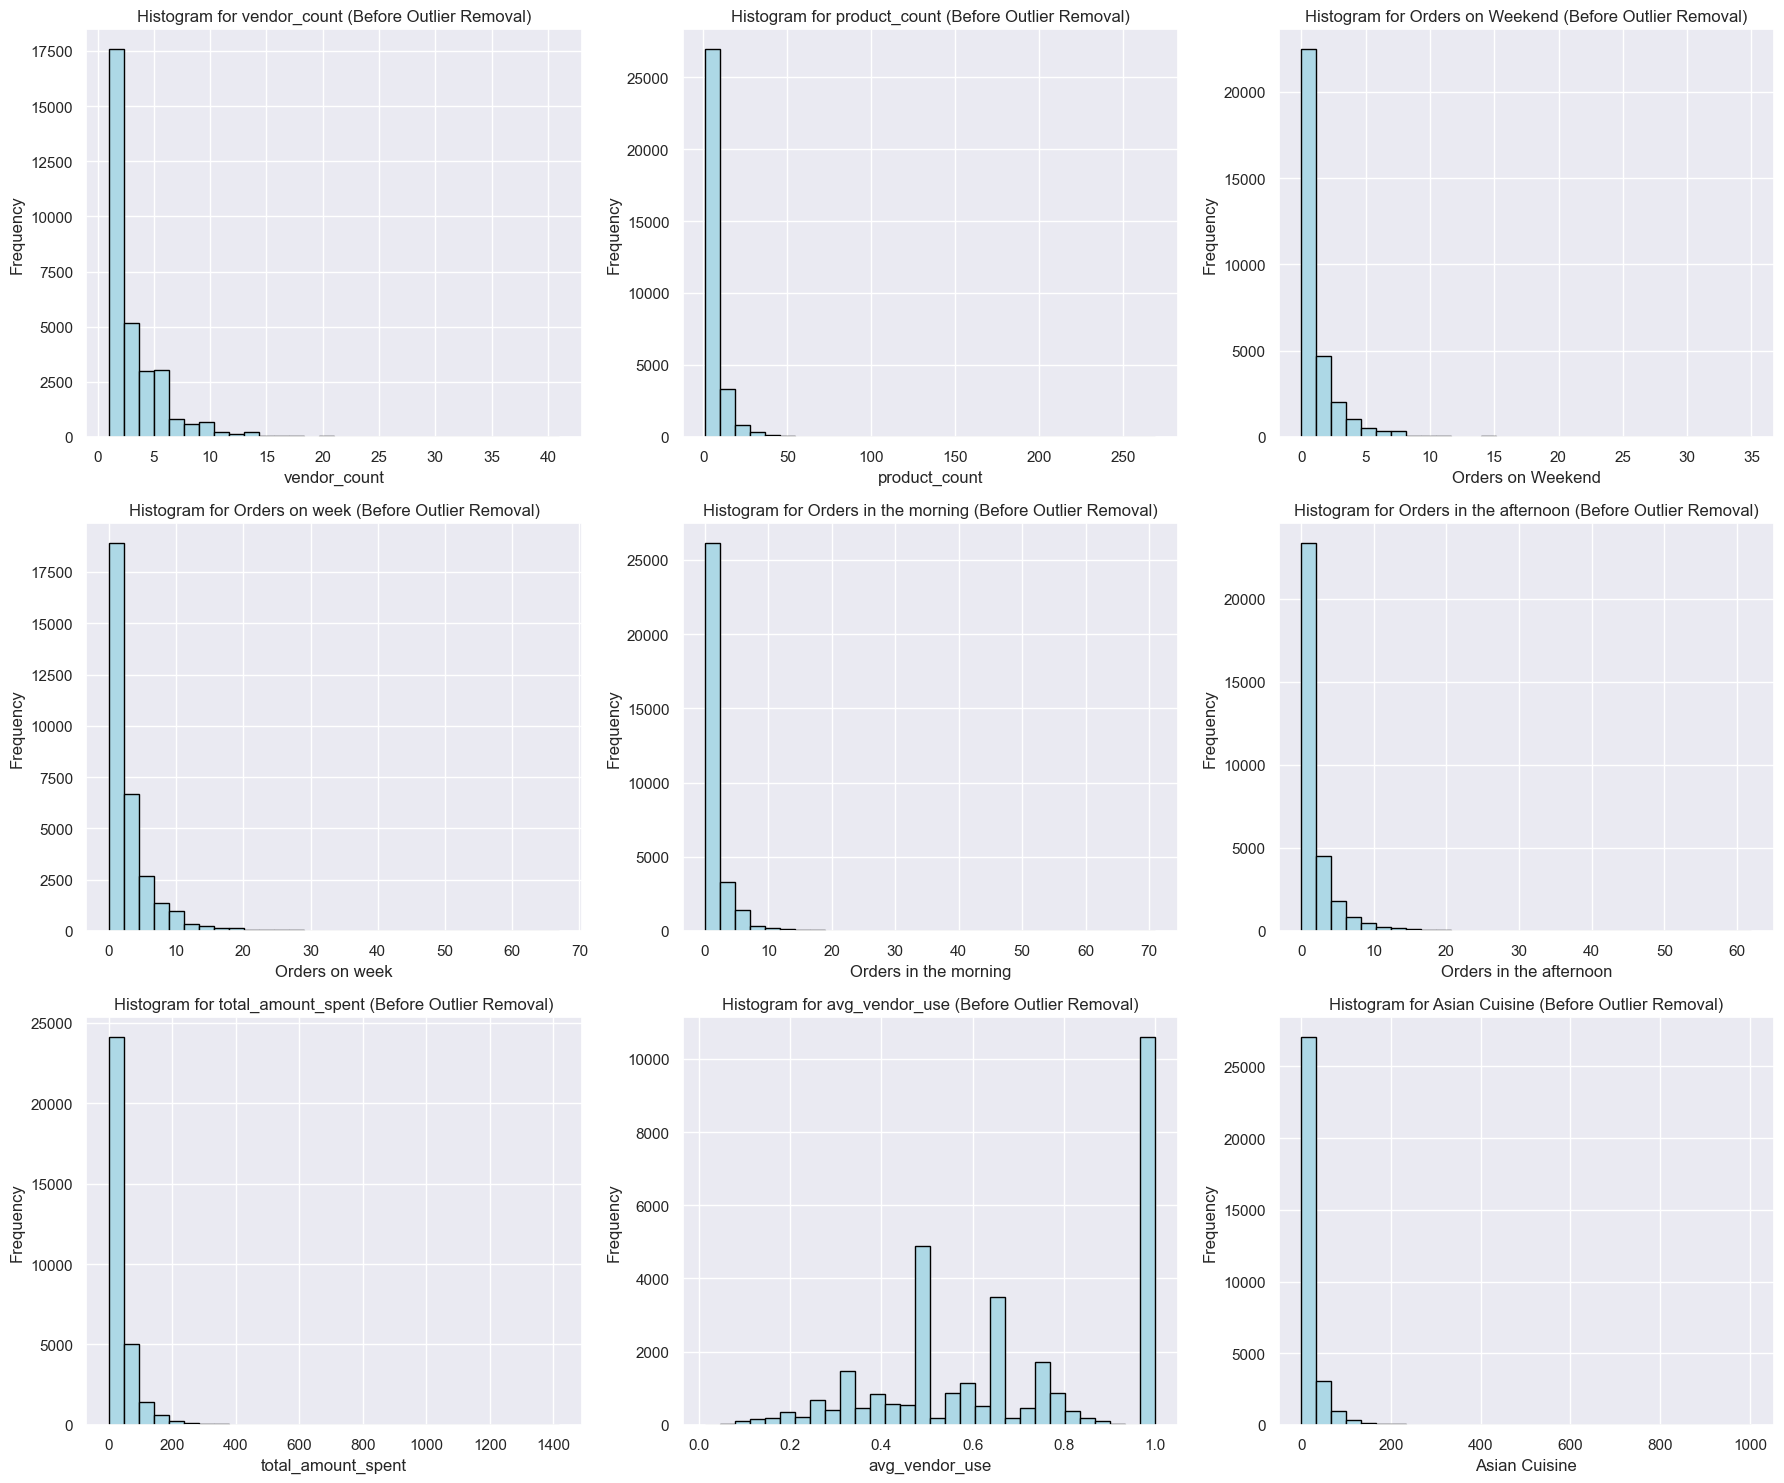

In [418]:
# Columns to visualize
columns_to_plot = ['vendor_count', 'product_count', 'Orders on Weekend', 'Orders on week',
                   'Orders in the morning', 'Orders in the afternoon',
                   'total_amount_spent', 'avg_vendor_use', 'Asian Cuisine']

# Visualization Function
def plot_before_outliers(data, columns):
    # Set up the figure layout dynamically (3 columns per row)
    rows = len(columns) // 3 + (len(columns) % 3 > 0)
    fig, axes = plt.subplots(rows, 3, figsize=(18, rows * 5))
    axes = axes.flatten()  # Flatten the axes for easy iteration

    # Iterate over features to create boxplots and histograms
    for i, column in enumerate(columns):
        # Boxplot
        sns.boxplot(x=data[column], ax=axes[i], color="skyblue")
        axes[i].set_title(f"Boxplot for {column} (Before Outlier Removal)")
        axes[i].set_xlabel(column)

    # Hide unused subplots
    for i in range(len(columns), len(axes)):
        axes[i].axis("off")  # Turn off unused axes

    plt.tight_layout()
    plt.show()

    # Plot histograms
    fig, axes = plt.subplots(rows, 3, figsize=(18, rows * 5))
    axes = axes.flatten()
    for i, column in enumerate(columns):
        axes[i].hist(data[column], bins=30, color="lightblue", edgecolor="black")
        axes[i].set_title(f"Histogram for {column} (Before Outlier Removal)")
        axes[i].set_xlabel(column)
        axes[i].set_ylabel("Frequency")

    # Hide unused subplots
    for i in range(len(columns), len(axes)):
        axes[i].axis("off")

    plt.tight_layout()
    plt.show()

# Visualize the original data (before outlier removal)
plot_before_outliers(df_original, columns_to_plot)


#### <span style="color:salmon"> 1. "manually" filtering the dataset's outliers </span>

In [420]:
# Define manual thresholds for outlier filtering
filters1 = (
    (df['vendor_count'] <= 20)
    &
    (df['product_count'] <= 50)
    &
    (df['Orders on Weekend'] <= 30)
    &
    (df['total_amount_spent'] <= 1000)
    &
    (df['avg_vendor_use'] >= 0.1)
    &
    (df['Asian Cuisine'] <= 500)
    &
    (df['Orders on week'] <= 20)
    &
    (df['Orders in the morning'] <= 10)
    &
    (df['Orders in the afternoon'] <= 15)
)

# Apply the filters to the DataFrame
df_1 = df[filters1]

In [421]:
print('Percentage of data kept after removing outliers:', 100*(np.round(df_1.shape[0] / df_original.shape[0], 4)))

Percentage of data kept after removing outliers: 97.8


#### <span style="color:salmon"> 2. Outlier removal using only the IQR method </span>

In [423]:
import pandas as pd
import numpy as np

# Calculate IQR for each metric
q25 = df[metric_features].quantile(0.25)
q75 = df[metric_features].quantile(0.75)
iqr = q75 - q25

upper_lim = q75 + 1.5 * iqr
lower_lim = q25 - 1.5 * iqr

# Create a combined filter for all metrics
filters2 = pd.Series(True, index=df.index)  # Start with all True

# Iterate over metrics to refine the filter
for metric in metric_features:
    llim = lower_lim[metric]
    ulim = upper_lim[metric]
    filters2 = filters2 & df[metric].between(llim, ulim, inclusive='both')  # Combine filters element-wise

# Apply the filter to the DataFrame
df_2 = df[filters2]

# Print percentage of data retained
print('Percentage of data kept after removing outliers:',
      np.round(df_2.shape[0] / df.shape[0] * 100, 2))


Percentage of data kept after removing outliers: 30.12


#### <span style="color:salmon"> 3. Combining different outlier methods </span>


In [425]:
df_3 = df[(filters1 | filters2)]
print('Percentage of data kept after removing outliers:', 100*(np.round(df_3.shape[0] / df_original.shape[0], 4)))

Percentage of data kept after removing outliers: 97.8


### Analysis of the Results:
- **Manual Thresholding `(filters1)`**:
    - Percentage Kept: 97.8% of the data is retained.
      
- **IQR-Based Filtering `(filters2)`**:
    - Percentage Kept: 30.12% of the data is retained.
    - The wages range from 0 to a maximum of 2,828,079
- **Combined Method `(filters1 | filters2)`**:
    - Percentage Kept: 97.8% of the data is retained (same as manual thresholding).
- **As a rule of thumb, try not to remove more than 5% of your rows. Use manual thresholding (filters1), as it aligns with known business rules and expected ranges.**
      

In [427]:
df = df_1.copy()

#### <span style="color:salmon"> Outlier threshold value </span>

In [429]:
worked_with = df[['vendor_count', 'product_count', 'Orders on Weekend','Orders on week',
                  'Orders in the morning','Orders in the afternoon','total_amount_spent', 'avg_vendor_use', 'Asian Cuisine']]

In [430]:
# Filter columns NOT in 'worked_with'
df_filtered = df[[col for col in df.columns if col not in worked_with]]

# Display the filtered DataFrame
df_filtered.describe()

,is_chain,total orders,Orders in night,American Cuisine,European Cuisine,Snacks & Beverages,Other Cuisine,order_frequency,American_ratio,Asian_ratio,European_ratio,Snacks_Beverages_ratio,Other_Cuisine_ratio
count,31034.000000,31034.000000,31034.000000,31034.000000,31034.000000,31034.000000,31034.000000,31034.000000,31034.000000,31034.000000,31034.000000,31034.000000,31034.000000
mean,2.515886,3.421151,0.764065,4.597876,2.882364,7.441136,4.731128,49.203284,0.140836,0.405364,0.097282,0.175701,0.180816
std,2.873091,3.124592,1.459829,10.597644,9.041981,18.821913,10.703316,29.551807,0.271075,0.394165,0.249646,0.310184,0.311448
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-22.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,26.666667,0.000000,0.000000,0.000000,0.000000,0.000000
50%,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,55.666667,0.000000,0.328189,0.000000,0.000000,0.000000
75%,3.000000,4.000000,1.000000,5.400000,0.000000,6.180000,5.560000,75.222222,0.159805,0.782528,0.000000,0.240346,0.270762
max,30.000000,25.000000,25.000000,231.750000,150.880000,519.700000,238.020000,90.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [431]:
print((df['is_chain']>20).value_counts())
print((df['Orders in night']>10).value_counts())
print((df['American Cuisine']>100).value_counts())
print((df['European Cuisine']>50).value_counts())
print((df['Snacks & Beverages']>100).value_counts())
print((df['Other Cuisine']>100).value_counts())

is_chain
False    31003
True        31
Name: count, dtype: int64
Orders in night
False    30970
True        64
Name: count, dtype: int64
American Cuisine
False    31008
True        26
Name: count, dtype: int64
European Cuisine
False    30803
True       231
Name: count, dtype: int64
Snacks & Beverages
False    30795
True       239
Name: count, dtype: int64
Other Cuisine
False    31004
True        30
Name: count, dtype: int64


In [432]:
# Define a dictionary of columns and their corresponding thresholds
thresholds = {
    'is_chain': 20,
    'Orders in night': 10,
    'American Cuisine': 100,
    'European Cuisine': 50,
    'Snacks & Beverages': 100,
    'Other Cuisine': 100
}

# Apply thresholds to each column
for col, threshold in thresholds.items():
    df[col] = df[col].clip(upper=threshold)

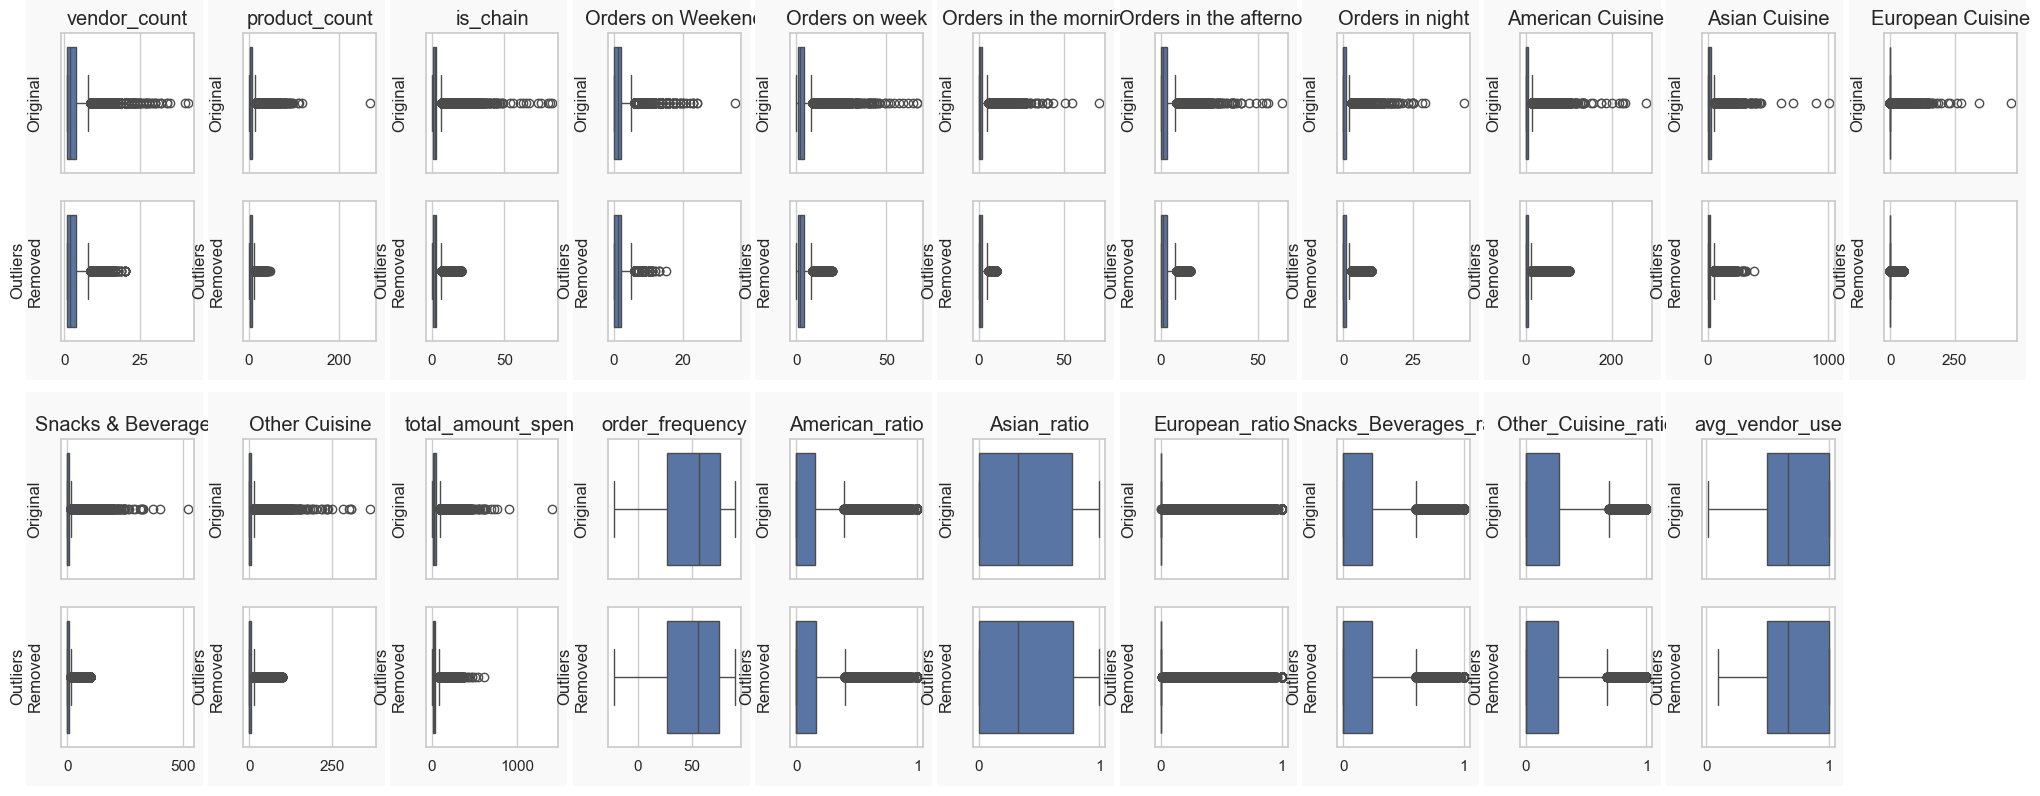

In [433]:
import seaborn as sns
from math import ceil
sns.set_style('whitegrid')
frows = 2
fcols = ceil(len(metric_features) / frows)

fig = plt.figure(figsize=(20,8))
subfigs = fig.subfigures(frows, fcols, wspace=.03, hspace=.03)

for sfig, feat in zip(subfigs.flatten(), metric_features):
    axes = sfig.subplots(2,1, sharex=True)

    sns.boxplot(x=df_original[feat], ax=axes[0])
    axes[0].set_ylabel('Original')
    axes[0].set_title(feat, fontsize='large')

    sns.boxplot(x=df[feat], ax=axes[1])
    axes[1].set_ylabel('Outliers\nRemoved')
    axes[1].set_xlabel('')
    # Subfigure Aesthetics
    sfig.set_facecolor("#F9F9F9")
    sfig.subplots_adjust(left=.2, right=.95, bottom=.1,)

# plt.savefig(os.path.join('..', 'figures', 'eda', 'boxplots_before_after_outliers.png'), dpi=200)
plt.show()


sns.set()

### Summary of Outlier Adjustments:
- **Outliers Removed or Capped**: Significant reductions in extreme values for key features such as `vendor_count`, `product_count`, `is_chain`, `Orders on Weekend`, and cuisine spending (`American Cuisine`, `European Cuisine`, etc.), ensuring tighter distributions.
- **Skewed Features Corrected**: Features like `Orders in the morning` and `Orders in night` are now less influenced by extreme values, creating more representative data.
- **Unchanged Features**: Ratio-based features (`American_ratio`, `Asian_ratio`, `avg_vendor_use`) remained consistent as they were already normalized.
#### Overall, the cleaning process effectively reduced noise from outliers, improving dataset reliability for further analysis.

## Feature Transform

In [436]:
df_encoding = df.copy()

#### <span style="color:salmon"> Handling missing values </span>

In [438]:
print(df_encoding['frequency_segment'].isnull().sum() / len(df_encoding['frequency_segment']))

0.0


In [439]:
# Get all rows where 'frequency_segment' is null
null_frequency_segment_rows = df_encoding[df_encoding['frequency_segment'].isnull()]

# Select only the categorical columns
categorical_columns = df_encoding.select_dtypes(include=['category', 'object']).columns
categorical_data_with_null_target = null_frequency_segment_rows[categorical_columns]

# Display the result
categorical_data_with_null_target

,customer_id,last_promo,payment_method,age_group,frequency_segment


In [440]:
df_encoding['frequency_segment'].value_counts()

frequency_segment
Unknown       17161
Infrequent     5487
Frequent       5451
Occasional     2935
Name: count, dtype: int64

**Approach: Impute Based on Most Common Feature Values**
- Group by Categorical Features: Group the data by 'last_promo', 'age_group', and 'order_frequency'.
- Find the Most Frequent frequency_segment: For each group, find the most common 'frequency_segment'.
- Impute Missing Values: Replace NaN in 'frequency_segment' with the most frequent value for the corresponding combination of features.

In [442]:
# Step 1: Group by the categorical features and find the mode for each group
most_frequent_segment = (
    df_encoding.groupby(['last_promo', 'age_group', 'order_frequency'])['frequency_segment']
    .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else None)  # Find the mode for each group
    .reset_index()
    .rename(columns={'frequency_segment': 'most_frequent_segment'})
)

# Step 2: Merge the most frequent values back to the original DataFrame
df_encoding = df_encoding.merge(
    most_frequent_segment,
    on=['last_promo', 'age_group', 'order_frequency'],
    how='left'
)

# Step 3: Impute missing 'frequency_segment' with the grouped mode
df_encoding['frequency_segment'] = df_encoding['frequency_segment'].fillna(df_encoding['most_frequent_segment'])

# Step 4: Impute any remaining missing values with the global mode
global_mode = df_encoding['frequency_segment'].mode()[0]
df_encoding['frequency_segment'] = df_encoding['frequency_segment'].fillna(global_mode)

# Step 5: Drop the helper column
df_encoding = df_encoding.drop(columns=['most_frequent_segment'])

# Verify no missing values remain
print(df_encoding['frequency_segment'].isnull().sum())  # Should print 0


/var/folders/_s/_rkc5yf52mjg60_cwkkrw5yc0000gn/T/ipykernel_1354/480970205.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_encoding.groupby(['last_promo', 'age_group', 'order_frequency'])['frequency_segment']


0


In [443]:
df_encoding['frequency_segment'].value_counts()

frequency_segment
Unknown       17161
Infrequent     5487
Frequent       5451
Occasional     2935
Name: count, dtype: int64

#### <span style="color:salmon"> Encoding Categoricla Data </span>

In [445]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, OrdinalEncoder

In [446]:
categorical_features = df_encoding.select_dtypes(include=['category','object']).columns.tolist()

In [447]:
df_encoding[categorical_features].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31034 entries, 0 to 31033
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   customer_id        31034 non-null  object  
 1   last_promo         31034 non-null  object  
 2   payment_method     31034 non-null  object  
 3   age_group          31034 non-null  category
 4   frequency_segment  31034 non-null  category
dtypes: category(2), object(3)
memory usage: 788.4+ KB


In [448]:
print(df_encoding['last_promo'].unique())
print(df_encoding['payment_method'].unique())
print(df_encoding['order_frequency'].unique())
print(df_encoding['age_group'].unique())
print(df_encoding['frequency_segment'].unique())

['DELIVERY' 'DISCOUNT' 'No Discount' 'FREEBIE']
['DIGI' 'CASH' 'CARD']
[  1.           2.           3.         ... -11.          -7.33333333
  -3.14285714]
['Young', 'Middle-Aged', 'Senior']
Categories (3, object): ['Young' < 'Middle-Aged' < 'Senior']
['Infrequent', 'Occasional', 'Frequent', 'Unknown']
Categories (4, object): ['Infrequent' < 'Occasional' < 'Frequent' < 'Unknown']


#### <span style="color:salmon">1. Label Encoding </span>

In [450]:
label_encoder = LabelEncoder()
df_encoding['frequency_segment'] = label_encoder.fit_transform(df_encoding['frequency_segment']).astype(int)

#### <span style="color:salmon">2. Encode Ordinal Features</span>

In [452]:
# Define the order for ordinal features
age_group_order = ['Young', 'Middle-Aged', 'Senior']
ordinal_encoder = OrdinalEncoder(categories=[age_group_order])

# Apply encoding to 'age_group'
df_encoding['age_group'] = ordinal_encoder.fit_transform(df_encoding[['age_group']]).astype(int)

#### <span style="color:salmon">3. One-Hot Encode Nominal Features</span>


In [454]:
nominal_features = ['last_promo', 'payment_method']
onehot_encoder = OneHotEncoder(drop='first', sparse_output=False)  # drop='first' avoids multicollinearity

# Perform One-Hot Encoding
onehot_encoded = pd.DataFrame(
    onehot_encoder.fit_transform(df_encoding[nominal_features]),
    columns=onehot_encoder.get_feature_names_out(nominal_features),
    index=df_encoding.index
)

# Drop original nominal features and concatenate the one-hot encoded columns
df_encoding = df_encoding.drop(columns=nominal_features).join(onehot_encoded)

In [455]:
df_encoding.head()

,customer_id,vendor_count,product_count,is_chain,total orders,Orders on Weekend,Orders on week,Orders in the morning,Orders in the afternoon,Orders in night,...,Asian_ratio,European_ratio,Snacks_Beverages_ratio,Other_Cuisine_ratio,avg_vendor_use,last_promo_DISCOUNT,last_promo_FREEBIE,last_promo_No Discount,payment_method_CASH,payment_method_DIGI
0,1b8f824d5e,2,5,1,1,2,0,0,2,0,...,1.000000,0.0,0.0,0.0,0.400000,0.0,0.0,0.0,0.0,1.0
1,5d272b9dcb,2,2,2,1,2,0,2,0,0,...,0.332639,0.0,0.0,0.0,1.000000,1.0,0.0,0.0,0.0,1.0
2,f6d1b2ba63,1,2,2,1,2,0,2,0,0,...,0.000000,0.0,0.0,0.0,0.500000,1.0,0.0,0.0,1.0,0.0
3,180c632ed8,2,3,1,2,1,1,1,1,0,...,1.000000,0.0,0.0,0.0,0.666667,0.0,0.0,0.0,0.0,1.0
4,4eb37a6705,2,5,0,2,1,1,2,0,0,...,0.737193,0.0,0.0,0.0,0.400000,0.0,0.0,1.0,0.0,1.0


In [456]:
df_encoding['order_frequency'] = df_encoding['order_frequency'].astype(int)

In [457]:
df_encoding.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31034 entries, 0 to 31033
Data columns (total 30 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   customer_id              31034 non-null  object 
 1   vendor_count             31034 non-null  int64  
 2   product_count            31034 non-null  int64  
 3   is_chain                 31034 non-null  int64  
 4   total orders             31034 non-null  int64  
 5   Orders on Weekend        31034 non-null  int64  
 6   Orders on week           31034 non-null  int64  
 7   Orders in the morning    31034 non-null  int64  
 8   Orders in the afternoon  31034 non-null  int64  
 9   Orders in night          31034 non-null  int64  
 10  American Cuisine         31034 non-null  float64
 11  Asian Cuisine            31034 non-null  float64
 12  European Cuisine         31034 non-null  float64
 13  Snacks & Beverages       31034 non-null  float64
 14  Other Cuisine         

In [458]:
df_encoding.head()

,customer_id,vendor_count,product_count,is_chain,total orders,Orders on Weekend,Orders on week,Orders in the morning,Orders in the afternoon,Orders in night,...,Asian_ratio,European_ratio,Snacks_Beverages_ratio,Other_Cuisine_ratio,avg_vendor_use,last_promo_DISCOUNT,last_promo_FREEBIE,last_promo_No Discount,payment_method_CASH,payment_method_DIGI
0,1b8f824d5e,2,5,1,1,2,0,0,2,0,...,1.000000,0.0,0.0,0.0,0.400000,0.0,0.0,0.0,0.0,1.0
1,5d272b9dcb,2,2,2,1,2,0,2,0,0,...,0.332639,0.0,0.0,0.0,1.000000,1.0,0.0,0.0,0.0,1.0
2,f6d1b2ba63,1,2,2,1,2,0,2,0,0,...,0.000000,0.0,0.0,0.0,0.500000,1.0,0.0,0.0,1.0,0.0
3,180c632ed8,2,3,1,2,1,1,1,1,0,...,1.000000,0.0,0.0,0.0,0.666667,0.0,0.0,0.0,0.0,1.0
4,4eb37a6705,2,5,0,2,1,1,2,0,0,...,0.737193,0.0,0.0,0.0,0.400000,0.0,0.0,1.0,0.0,1.0


In [459]:
df_encoding.columns

Index(['customer_id', 'vendor_count', 'product_count', 'is_chain',
       'total orders', 'Orders on Weekend', 'Orders on week',
       'Orders in the morning', 'Orders in the afternoon', 'Orders in night',
       'American Cuisine', 'Asian Cuisine', 'European Cuisine',
       'Snacks & Beverages', 'Other Cuisine', 'total_amount_spent',
       'order_frequency', 'age_group', 'frequency_segment', 'American_ratio',
       'Asian_ratio', 'European_ratio', 'Snacks_Beverages_ratio',
       'Other_Cuisine_ratio', 'avg_vendor_use', 'last_promo_DISCOUNT',
       'last_promo_FREEBIE', 'last_promo_No Discount', 'payment_method_CASH',
       'payment_method_DIGI'],
      dtype='object')

In [460]:
from sklearn.preprocessing import StandardScaler

# Ensure metric_features is a valid list of columns
metric_features = df_encoding[metric_features].columns.tolist()

# Exclude 'customer_id'
numerical_features = [col for col in metric_features if col != 'customer_id']

# Debugging
print("Numerical features:", numerical_features)

# Scale the numerical features
scaler = StandardScaler()
df_encoding[numerical_features] = scaler.fit_transform(df_encoding[numerical_features])

# Debugging
print(df_encoding.head())
print(df_encoding[numerical_features].describe())




Numerical features: ['vendor_count', 'product_count', 'is_chain', 'Orders on Weekend', 'Orders on week', 'Orders in the morning', 'Orders in the afternoon', 'Orders in night', 'American Cuisine', 'Asian Cuisine', 'European Cuisine', 'Snacks & Beverages', 'Other Cuisine', 'total_amount_spent', 'order_frequency', 'American_ratio', 'Asian_ratio', 'European_ratio', 'Snacks_Beverages_ratio', 'Other_Cuisine_ratio', 'avg_vendor_use']
  customer_id  vendor_count  product_count  is_chain  total orders  \
0  1b8f824d5e     -0.406527      -0.012147 -0.530502             1   
1  5d272b9dcb     -0.406527      -0.635255 -0.179832             1   
2  f6d1b2ba63     -0.839745      -0.635255 -0.179832             1   
3  180c632ed8     -0.406527      -0.427552 -0.530502             2   
4  4eb37a6705     -0.406527      -0.012147 -0.881173             2   

   Orders on Weekend  Orders on week  Orders in the morning  \
0           0.620842       -1.037124              -0.730228   
1           0.620842  

In [461]:
df = df_encoding.copy()

In [462]:
df = df.drop(columns=['customer_id'])

In [463]:
df.columns

Index(['vendor_count', 'product_count', 'is_chain', 'total orders',
       'Orders on Weekend', 'Orders on week', 'Orders in the morning',
       'Orders in the afternoon', 'Orders in night', 'American Cuisine',
       'Asian Cuisine', 'European Cuisine', 'Snacks & Beverages',
       'Other Cuisine', 'total_amount_spent', 'order_frequency', 'age_group',
       'frequency_segment', 'American_ratio', 'Asian_ratio', 'European_ratio',
       'Snacks_Beverages_ratio', 'Other_Cuisine_ratio', 'avg_vendor_use',
       'last_promo_DISCOUNT', 'last_promo_FREEBIE', 'last_promo_No Discount',
       'payment_method_CASH', 'payment_method_DIGI'],
      dtype='object')

### Save data for clusering

In [465]:

# Now you can save the DataFrame to the CSV file
df.to_csv("data_save_for_clustering.csv", index=False)